# 02-2. EDA — 세그먼트 지표·주파수 구조·정상 전류 기준

## 현재 분석 흐름
1. 전체 세그먼트의 지표와 길이 영향을 확인한다.
2. 전류·상부 진동·하부 진동의 FFT 구조를 시간·길이별로 비교한다.
3. 정상 전류의 공통 주기를 구하고 중심 고정 사인 잔차를 기존 자유 적합과 비교한다.
4. 다음 단계로 상·하부 진동을 자세히 확인한다.

전체 길이를 포함한다. 라벨은 파일 단위이며 세그먼트별 실제 정답이 아니다.
표는 기본적으로 숨기고 그래프 중심으로 표시한다 (`SHOW_TABLES=True`일 때 표 표시).
03은 규칙 기반 오경보·미탐 평가를 담당한다. 이 노트의 피처 후보 채택은 아직 확정하지 않는다.


## 0. 설정 및 전체 세그먼트 피처 생성

03과 동일한 피처 정의를 사용한다. 결측은 0으로 대체하지 않는다.


In [1]:
import os, warnings
from pathlib import Path
 
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import font_manager

warnings.filterwarnings("ignore")
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 60)

# 현재 환경의 한글 폰트를 직접 등록한다 (기존 Matplotlib 캐시와 무관하게 적용).
for _font_path in [Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
                   Path("/mnt/c/Windows/Fonts/malgun.ttf")]:
    if _font_path.exists():
        font_manager.fontManager.addfont(str(_font_path))

_avail = {f.name for f in font_manager.fontManager.ttflist}
for _f in ["NanumGothic", "NanumBarunGothic", "Malgun Gothic", "AppleGothic", "DejaVu Sans"]:
    if _f in _avail:
        mpl.rcParams["font.family"] = _f
        break
mpl.rcParams["axes.unicode_minus"] = False
mpl.rcParams["mathtext.fontset"] = "dejavusans"
mpl.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3,
                     "axes.titlesize": 10, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8})

DATA_DIR = Path(os.environ.get("KAMP_DATA_DIR", "/mnt/d/data/kamp_ai/press_anomaly_dataset"))
FS, GAP_THR = 10.0, 0.15
MIN_N    = 1           # 짧은 세그먼트도 전부 포함해 길이별 오류율 평가
COLOR    = {"normal": "#1f77b4", "outlier": "#d62728"}

normal  = pd.read_csv(DATA_DIR / "press_data_normal.csv", index_col=0, parse_dates=["TimeStamp"])
outlier = pd.read_csv(DATA_DIR / "outlier_data.csv",      index_col=0, parse_dates=["TimeStamp"])
DFS = {"normal": normal, "outlier": outlier}

def make_segments(df):
    d = df["TimeStamp"].diff().dt.total_seconds()
    out = df.copy(); out["seg_id"] = (d > GAP_THR).cumsum().values
    return out

SEG = {k: make_segments(df) for k, df in DFS.items()}
print({k: len(v.seg_id.unique()) for k, v in SEG.items()}, "개 세그먼트")
# 표는 기본적으로 숨긴다. 필요할 때 True로 변경한다.
SHOW_TABLES = False

def display_table(table):
    if SHOW_TABLES:
        display(table)


{'normal': 599, 'outlier': 21} 개 세그먼트


In [2]:
def band_purity(x, fs=FS, fmin=1/2.2, fmax=1/0.9):
    n = len(x); x = np.asarray(x, float) - np.mean(x)
    F = np.fft.rfft(x); freqs = np.fft.rfftfreq(n, d=1/fs)
    P = np.abs(F) ** 2
    band = (freqs >= fmin) & (freqs <= fmax)
    tot = P[1:].sum()
    return P[band].max() / tot if tot > 0 and band.any() else np.nan

def envelope_cv(x, win=10):
    # 1초(10샘플) 서브윈도우별 RMS의 변동계수. 서브윈도우가 2개 미만(n<20)이면 NaN
    x = np.asarray(x, float)
    n = len(x) // win
    if n < 2: return np.nan
    chunks = x[:n*win].reshape(n, win)
    sub_rms = np.sqrt((chunks ** 2).mean(axis=1))
    m = sub_rms.mean()
    return sub_rms.std() / m if m > 0 else np.nan

def build_features(sdf, label):
    rows = []
    for sid, g in sdf.groupby("seg_id"):
        if len(g) < MIN_N: continue
        x0, x2 = g["AI0_Vibration"].values, g["AI2_Current"].values
        rows.append({
            "label": label, "seg_id": sid, "n": len(g), "t_start": g.TimeStamp.iloc[0],
            "ai0_rms": float(np.sqrt((x0 ** 2).mean())),
            "ai0_ac1": float(pd.Series(x0).autocorr(1)) if len(g) > 3 else np.nan,
            "purity":  band_purity(x2),
            "env_cv":  envelope_cv(x0),
        })
    return pd.DataFrame(rows)

F  = pd.concat([build_features(SEG[k], k) for k in DFS], ignore_index=True)
Fn = F[F.label == "normal"].sort_values("t_start").reset_index(drop=True)
Fo = F[F.label == "outlier"].sort_values("t_start").reset_index(drop=True)

print(f"normal {len(Fn)}개 (env_cv 결측 {Fn.env_cv.isna().sum()}개)")
print(f"outlier {len(Fo)}개 (env_cv 결측 {Fo.env_cv.isna().sum()}개: "
      f"seg {Fo.loc[Fo.env_cv.isna(),'seg_id'].tolist()})")
display_table(Fn[["ai0_rms","ai0_ac1","purity","env_cv"]].describe().round(4))

normal 599개 (env_cv 결측 147개)
outlier 21개 (env_cv 결측 8개: seg [0, 4, 5, 9, 10, 14, 19, 20])


In [3]:
EDA_FEATURES = ["ai0_rms", "purity", "env_cv", "ai0_ac1"]
LENGTH_LABELS = ["<5", "5~9", "10~14", "15~19", "20~29", "≥30"]
F["length_bin"] = pd.cut(F.n, bins=[0, 5, 10, 15, 20, 30, np.inf],
                         labels=LENGTH_LABELS, right=False)
F["duration_s"] = (F.n - 1) / FS
if SHOW_TABLES:
    display_table(F[["label", "seg_id", "n", "duration_s", "length_bin", "t_start"] + EDA_FEATURES])
    display_table(F.groupby("label")[EDA_FEATURES].describe().round(4))


## 1. 세그먼트별 지표 — 시간 변화

| 지표 | 대상 | 의미 |
|---|---|---|
| ai0_rms | 상부 진동 | 진동 크기 |
| purity | 전류 | 정상 주기대의 지배 FFT 파워 / 비DC 전체 파워 |
| env_cv | 상부 진동 | 10샘플 구간별 RMS 변동계수 (n<20이면 결측) |
| ai0_ac1 | 상부 진동 | lag-1 자기상관 (매우 짧거나 분산이 없으면 결측) |

정상/이상 파일은 서로 다른 날짜이므로 시간축을 분리한다. 같은 지표는 y축을 공유한다.
전류 purity는 주기 자체나 사인 적합도가 아니며, 길이에 따른 FFT 격자 영향을 받는다.


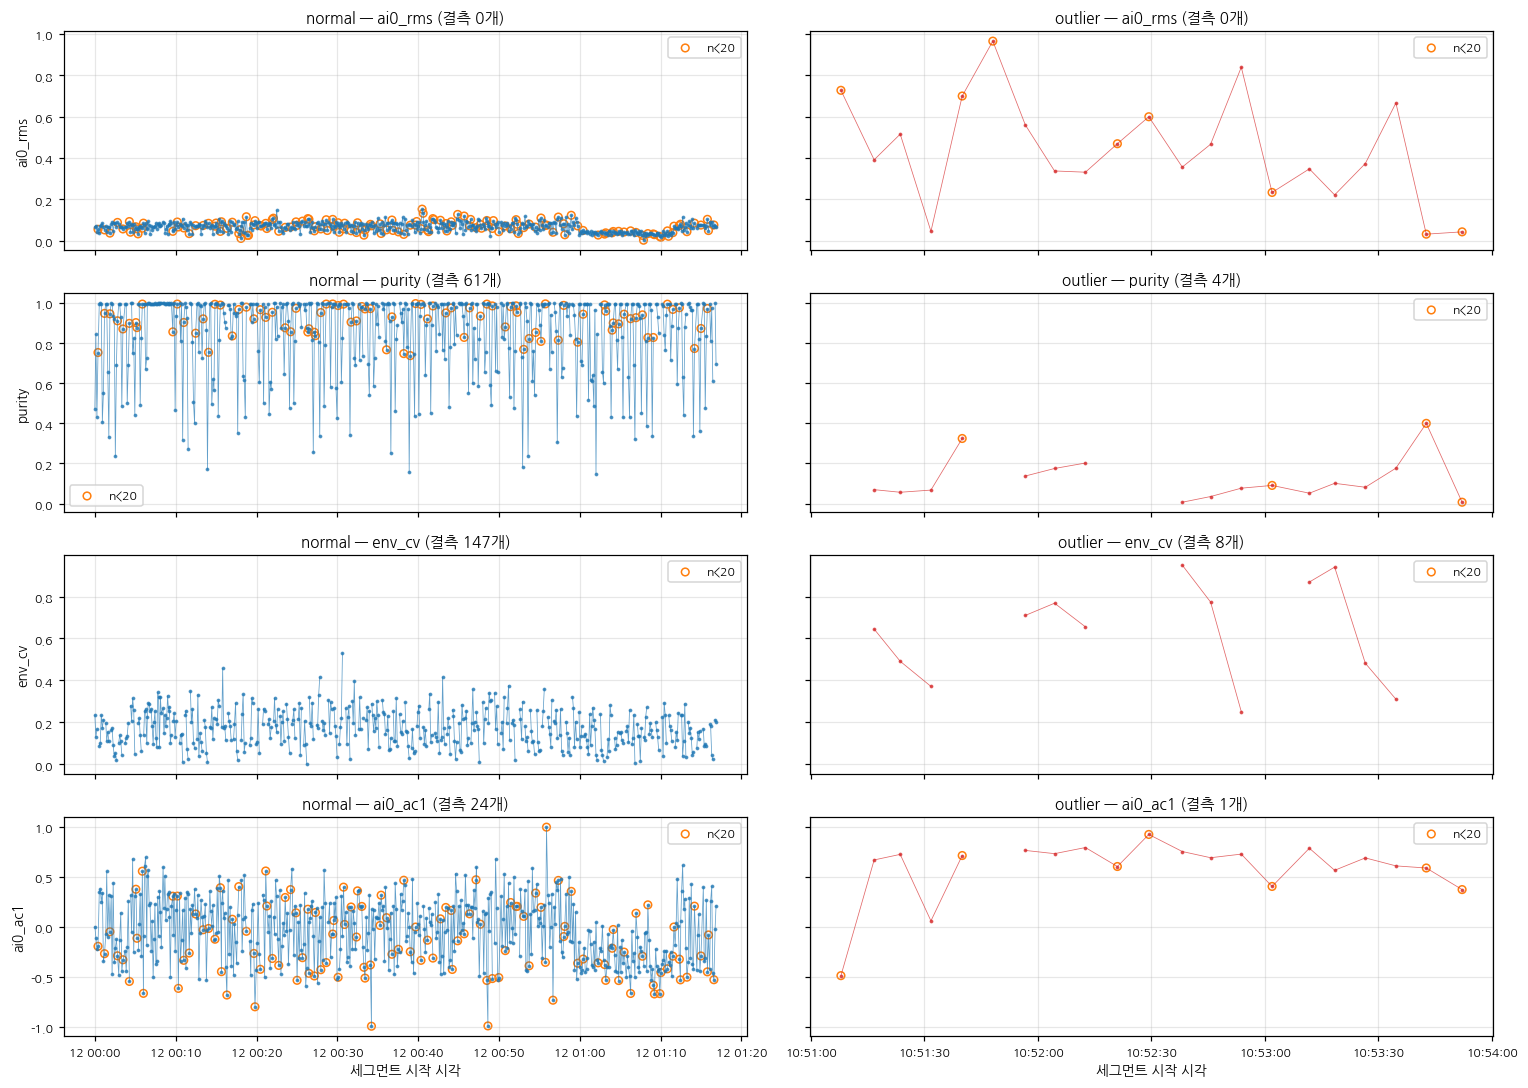

In [4]:
fig, axes = plt.subplots(4, 2, figsize=(14, 10), sharex="col", sharey="row")
for j, label in enumerate(["normal", "outlier"]):
    sub = F[F.label == label].sort_values("t_start")
    for i, feat in enumerate(EDA_FEATURES):
        ax = axes[i, j]
        ax.plot(sub.t_start, sub[feat], ".-", color=COLOR[label], ms=3, lw=.5, alpha=.7)
        short = (sub.n < 20) & sub[feat].notna()
        ax.scatter(sub.loc[short, "t_start"], sub.loc[short, feat],
                   facecolors="none", edgecolors="#ff7f0e", s=25, label="n<20")
        ax.set_title(f"{label} — {feat} (결측 {sub[feat].isna().sum()}개)")
        if j == 0: ax.set_ylabel(feat)
        ax.legend()
    axes[-1, j].set_xlabel("세그먼트 시작 시각")
plt.tight_layout(); plt.show()


### 1-1. 길이별 지표 분포·계산 가능 건수

짧은 세그먼트의 정보 부족과 실제 파형 변화를 구분한다.
결측은 정상값 0으로 채우지 않는다. 표는 필요할 때만 표시한다.


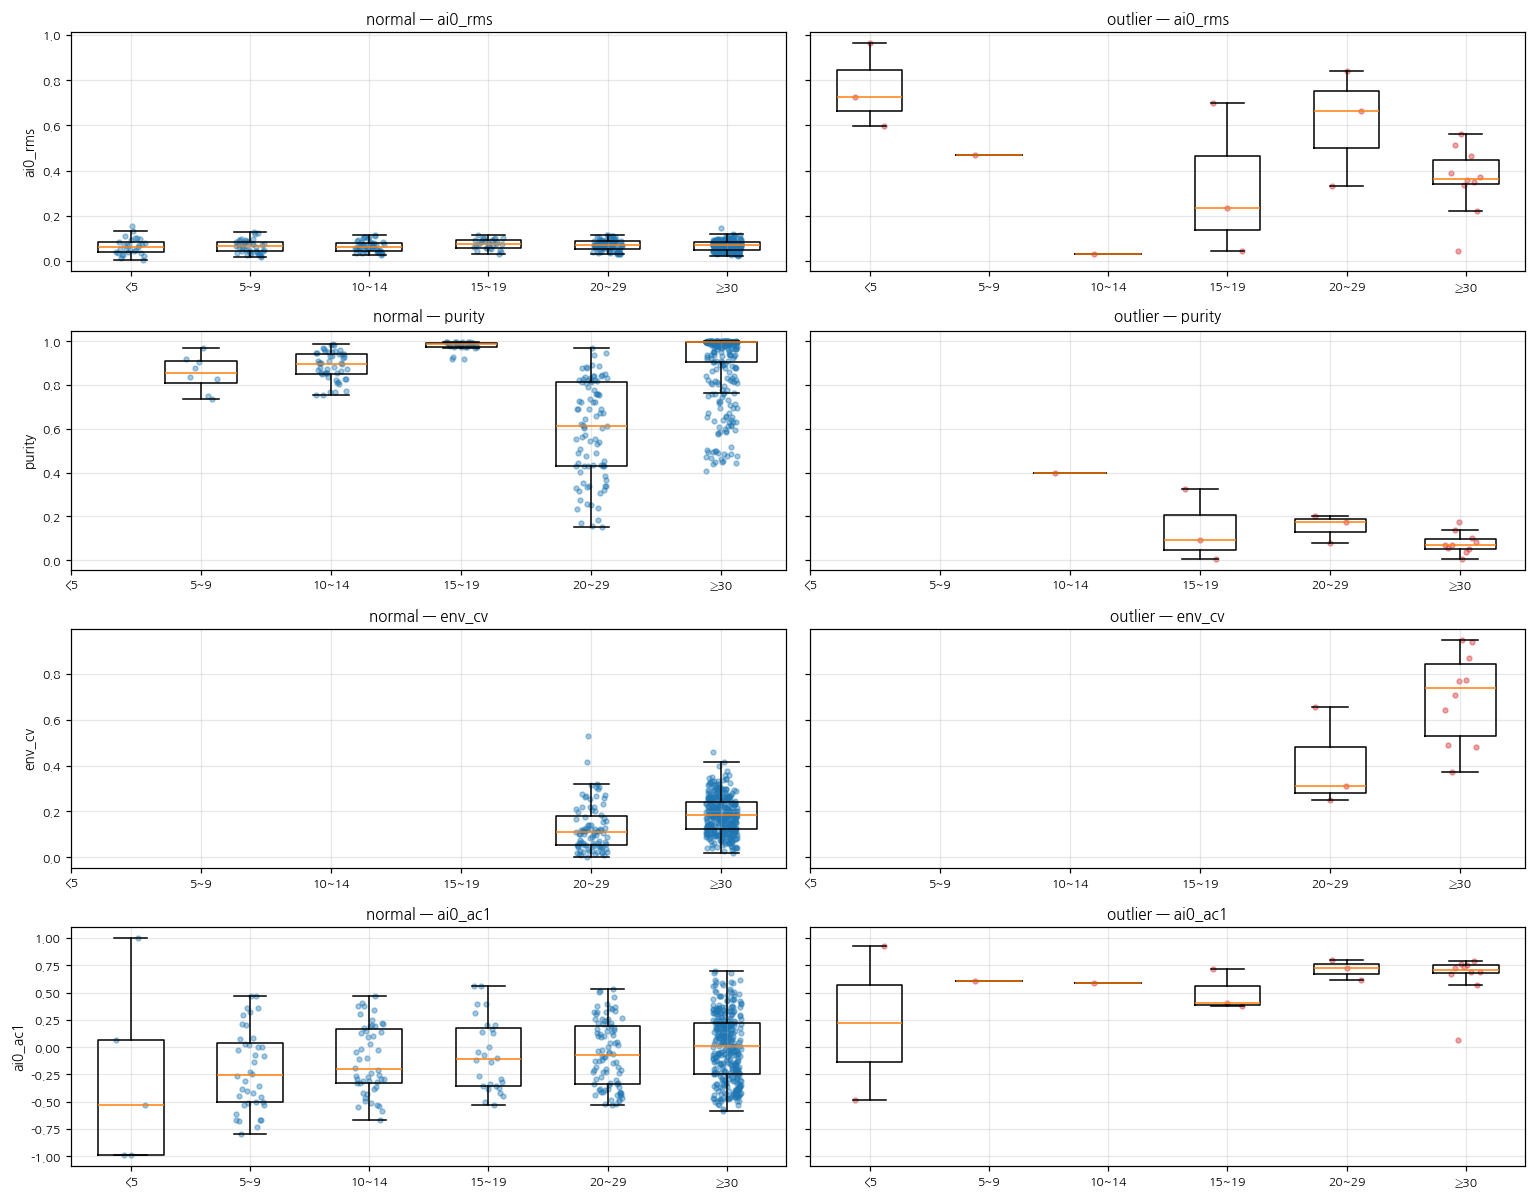

In [5]:
coverage = []
for (label, length), sub in F.groupby(["label", "length_bin"], observed=False):
    for feat in EDA_FEATURES:
        valid = sub[feat].notna().sum()
        coverage.append({"label": label, "길이": length, "지표": feat,
                         "전체": len(sub), "계산가능": valid, "결측": len(sub)-valid,
                         "중앙값": sub[feat].median()})
display_table(pd.DataFrame(coverage).round(4))
fig, axes = plt.subplots(4, 2, figsize=(14, 11), sharey="row")
for j, label in enumerate(["normal", "outlier"]):
    sub = F[F.label == label]
    for i, feat in enumerate(EDA_FEATURES):
        ax = axes[i, j]
        for pos, length in enumerate(LENGTH_LABELS):
            values = sub.loc[sub.length_bin == length, feat].dropna().to_numpy()
            if len(values):
                ax.boxplot([values], positions=[pos], widths=.55, showfliers=False)
                ax.scatter(pos + np.linspace(-.12, .12, len(values)), values,
                           s=10, alpha=.4, color=COLOR[label])
        ax.set_xticks(range(len(LENGTH_LABELS)), LENGTH_LABELS)
        ax.set_title(f"{label} — {feat}")
        if j == 0: ax.set_ylabel(feat)
plt.tight_layout(); plt.show()


## 2. 세그먼트별 FFT — 채널별 주파수 구조

전류·상부 진동·하부 진동을 각각 분석한다. 10Hz 샘플링의 관측 가능 범위는 **0~5Hz**이며,
고주파 성분의 실제 물리 주파수는 이 데이터만으로 복원하지 않는다.

평균 제거 후 직사각 창의 단측 파워 스펙트럼을 계산한다. 창·zero padding을 추가하지 않고
실제 FFT bin을 표시한다. 주파수 간격은 `FS/n`으로 짧은 세그먼트일수록 거칠다.
파워 합은 평균 제거 신호의 평균 제곱과 일치한다. 상대 파워는 비DC 전체 파워에 대한 비율이다.
n=1 또는 변동이 없는 신호에는 주파수 구조를 정의하지 않는다.

고정 구간 `(0,1]`, `(1,2]`, `(2,3]`, `(3,4]`, `(4,5]Hz`로 상대 파워를 집계하되,
FFT bin이 없는 구간은 결측으로 표시한다. 낮은 해상도의 세그먼트에서 대역이 비었다는 것은
그 주파수 성분이 없다는 뜻이 아니다. 세그먼트 간 신호를 이어 붙이지 않는다.


In [6]:
FFT_CHANNELS = ["AI2_Current", "AI0_Vibration", "AI1_Vibration"]
FFT_BANDS = [(0, 1), (1, 2), (2, 3), (3, 4), (4, 5)]
fft_rows, fft_summary = [], []
for label, sdf in SEG.items():
    for sid, g in sdf.groupby("seg_id"):
        size = len(g)
        for channel in FFT_CHANNELS:
            x = g[channel].to_numpy(dtype=float)
            centered = x - x.mean()
            freqs = np.fft.rfftfreq(size, d=1/FS)
            power = np.abs(np.fft.rfft(centered))**2 / size**2
            if size % 2 == 0:
                power[1:-1] *= 2
            else:
                power[1:] *= 2
            non_dc = freqs > 0
            total = power[non_dc].sum()
            usable = size > 1 and total > 0
            peak_idx = np.argmax(power[1:]) + 1 if usable else None
            row = {"label": label, "seg_id": sid, "n": size,
                   "t_start": g.TimeStamp.iloc[0], "channel": channel,
                   "df_hz": FS/size, "ac_power": total,
                   "peak_hz": freqs[peak_idx] if usable else np.nan,
                   "peak_share": power[peak_idx]/total if usable else np.nan}
            for lower, upper in FFT_BANDS:
                mask = (freqs > lower) & (freqs <= upper)
                row[f"({lower},{upper}]Hz"] = power[mask].sum()/total if usable and mask.any() else np.nan
            fft_summary.append(row)
            for idx in np.flatnonzero(non_dc):
                fft_rows.append({"label": label, "seg_id": sid, "n": size,
                                 "t_start": g.TimeStamp.iloc[0], "channel": channel,
                                 "frequency_hz": freqs[idx], "power": power[idx],
                                 "relative_power": power[idx]/total if usable else np.nan})
FFT = pd.DataFrame(fft_rows)
FFT_SEG = pd.DataFrame(fft_summary)
FFT_SEG["length_bin"] = pd.cut(FFT_SEG.n, [0,5,10,15,20,30,np.inf],
                               labels=LENGTH_LABELS, right=False)
print("세그먼트별 주파수 요약")
display_table(FFT_SEG.round(4))
print("라벨·채널별 FFT 해상도 및 지배 주파수 요약")
display_table(FFT_SEG.groupby(["label", "channel"])[["df_hz", "peak_hz", "peak_share", "ac_power"]].describe().round(4))


세그먼트별 주파수 요약
라벨·채널별 FFT 해상도 및 지배 주파수 요약


### 2-1. 시간에 따른 주파수 분포와 지배 주파수

위쪽은 각 세그먼트의 **실제 FFT bin**을 시작 시각에 배치한 상대 파워 지도다.
색은 세그먼트 내 상대 파워이며 세그먼트 사이 시간 공백은 보간하지 않는다.
아래쪽은 지배 bin 주파수다. n<20은 별도로 표시하여 시간 변화와 길이 영향을 함께 확인한다.


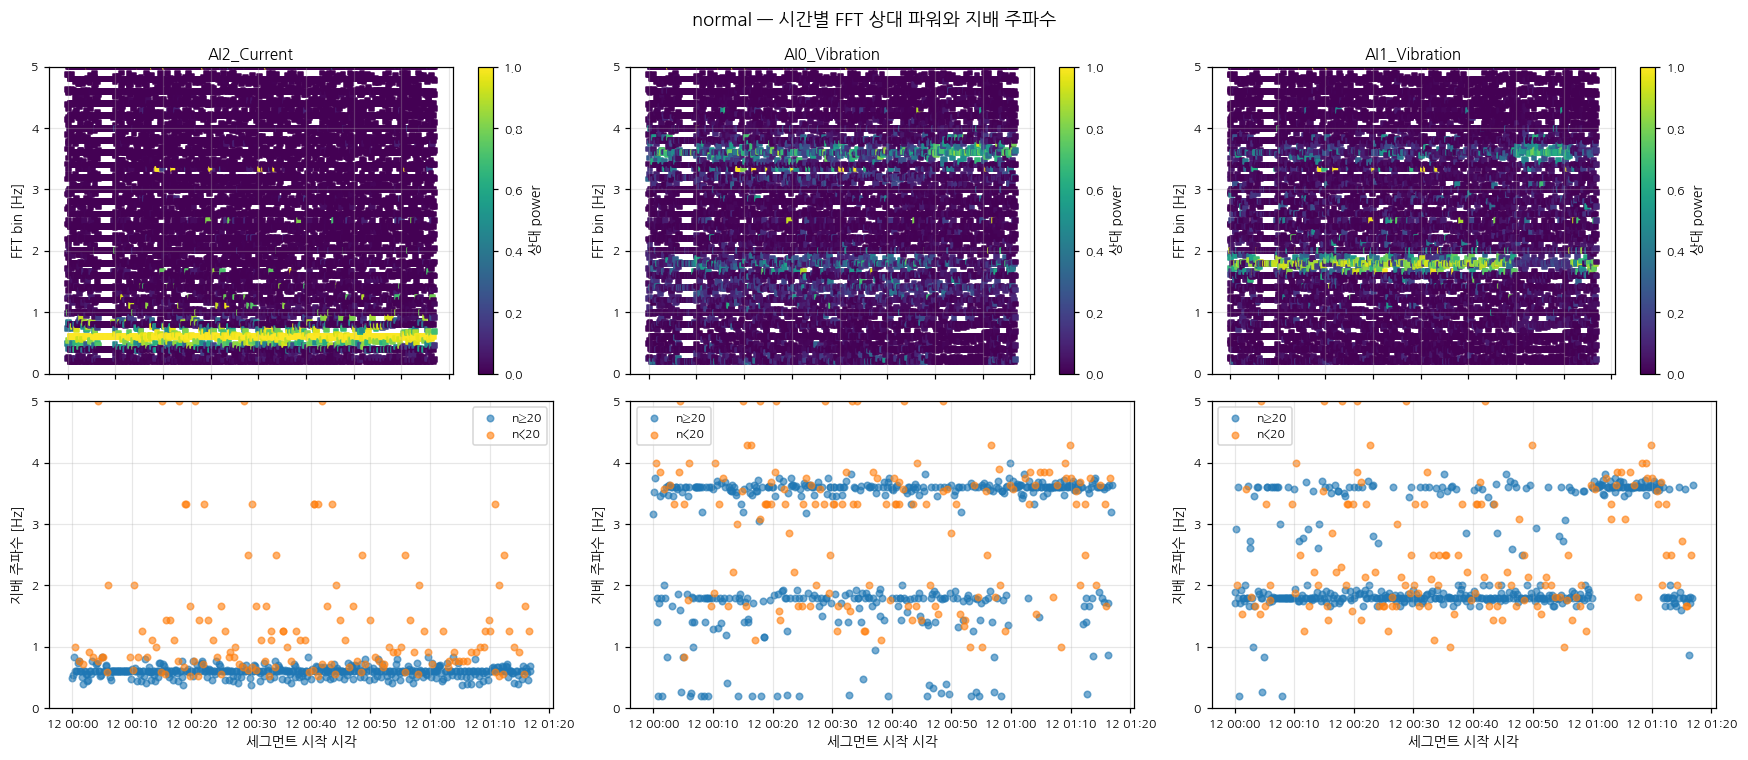

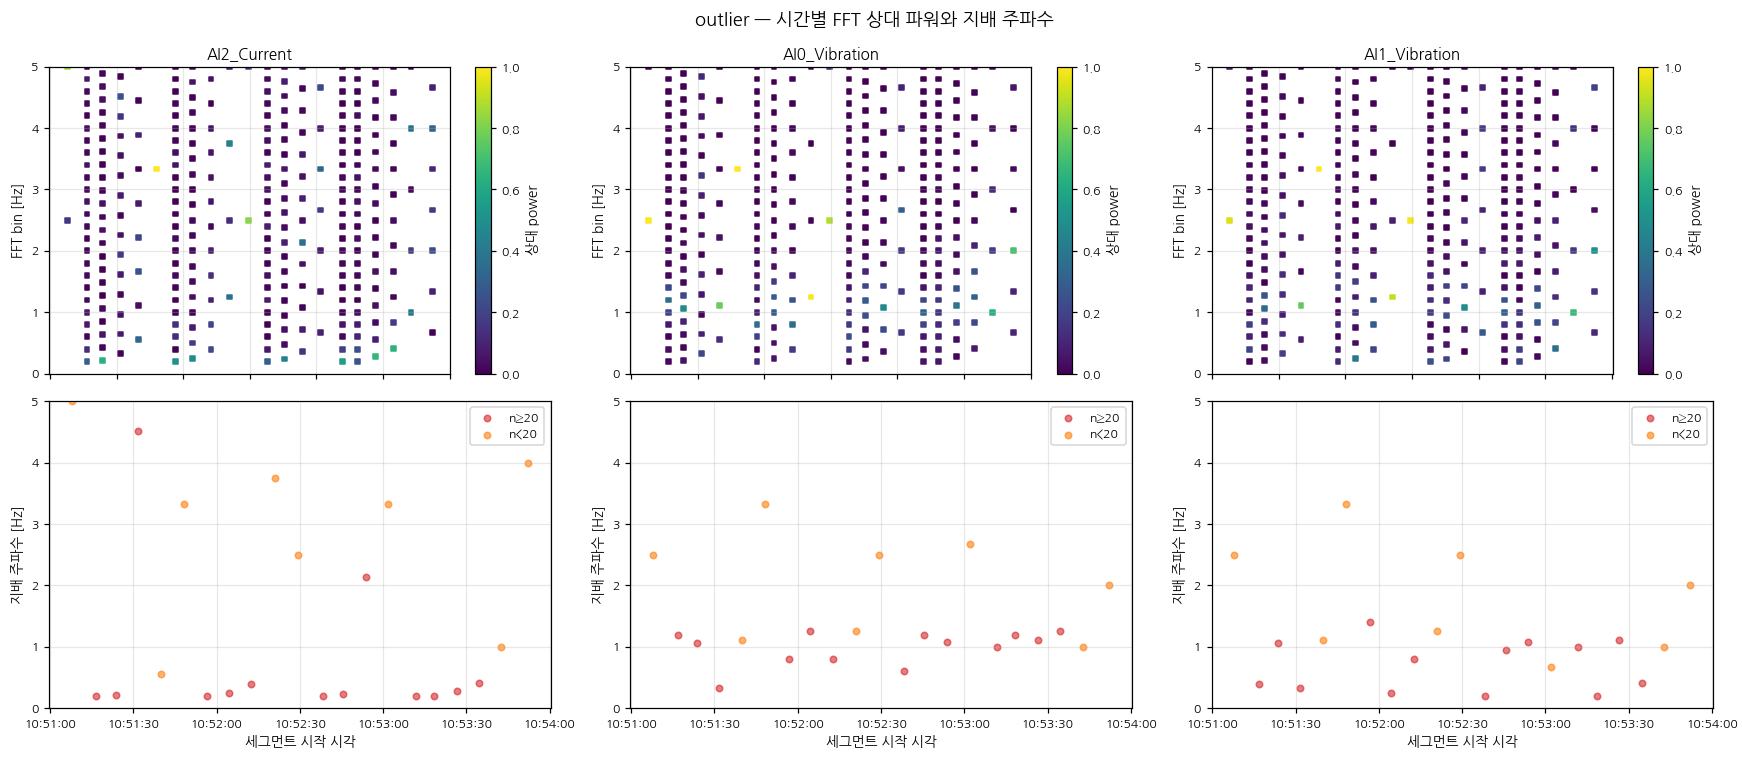

In [7]:
for label in ["normal", "outlier"]:
    fig, axes = plt.subplots(2, 3, figsize=(16, 7), sharex="col")
    for j, channel in enumerate(FFT_CHANNELS):
        bins = FFT[(FFT.label == label) & (FFT.channel == channel)].dropna(subset=["relative_power"])
        points = axes[0,j].scatter(bins.t_start, bins.frequency_hz, c=bins.relative_power,
                                   s=10, marker="s", cmap="viridis", vmin=0, vmax=1)
        axes[0,j].set_ylim(0,5); axes[0,j].set_ylabel("FFT bin [Hz]")
        axes[0,j].set_title(channel)
        fig.colorbar(points, ax=axes[0,j], label="相対 power".replace("相対", "상대"))
        sub = FFT_SEG[(FFT_SEG.label == label) & (FFT_SEG.channel == channel)]
        for short, color, name in [(False,COLOR[label],"n≥20"),(True,"#ff7f0e","n<20")]:
            picked = sub[(sub.n < 20) == short]
            axes[1,j].scatter(picked.t_start,picked.peak_hz,s=18,alpha=.6,color=color,label=name)
        axes[1,j].set_ylim(0,5); axes[1,j].set_ylabel("지배 주파수 [Hz]")
        axes[1,j].set_xlabel("세그먼트 시작 시각"); axes[1,j].legend()
    fig.suptitle(f"{label} — 시간별 FFT 상대 파워와 지배 주파수")
    plt.tight_layout(); plt.show()


### 2-2. 세그먼트 길이에 따른 주파수 구조

지배 주파수와 실제 길이를 함께 표시하고 길이별 고정 대역 상대 파워를 요약한다.
대역 평균에는 해당 대역에 FFT bin이 있는 세그먼트만 포함하며, 유효 건수도 함께 표시한다.
길이 때문에 지배 주파수가 특정 격자에 모이는 현상을 실제 주파수 변화와 구분해야 한다.


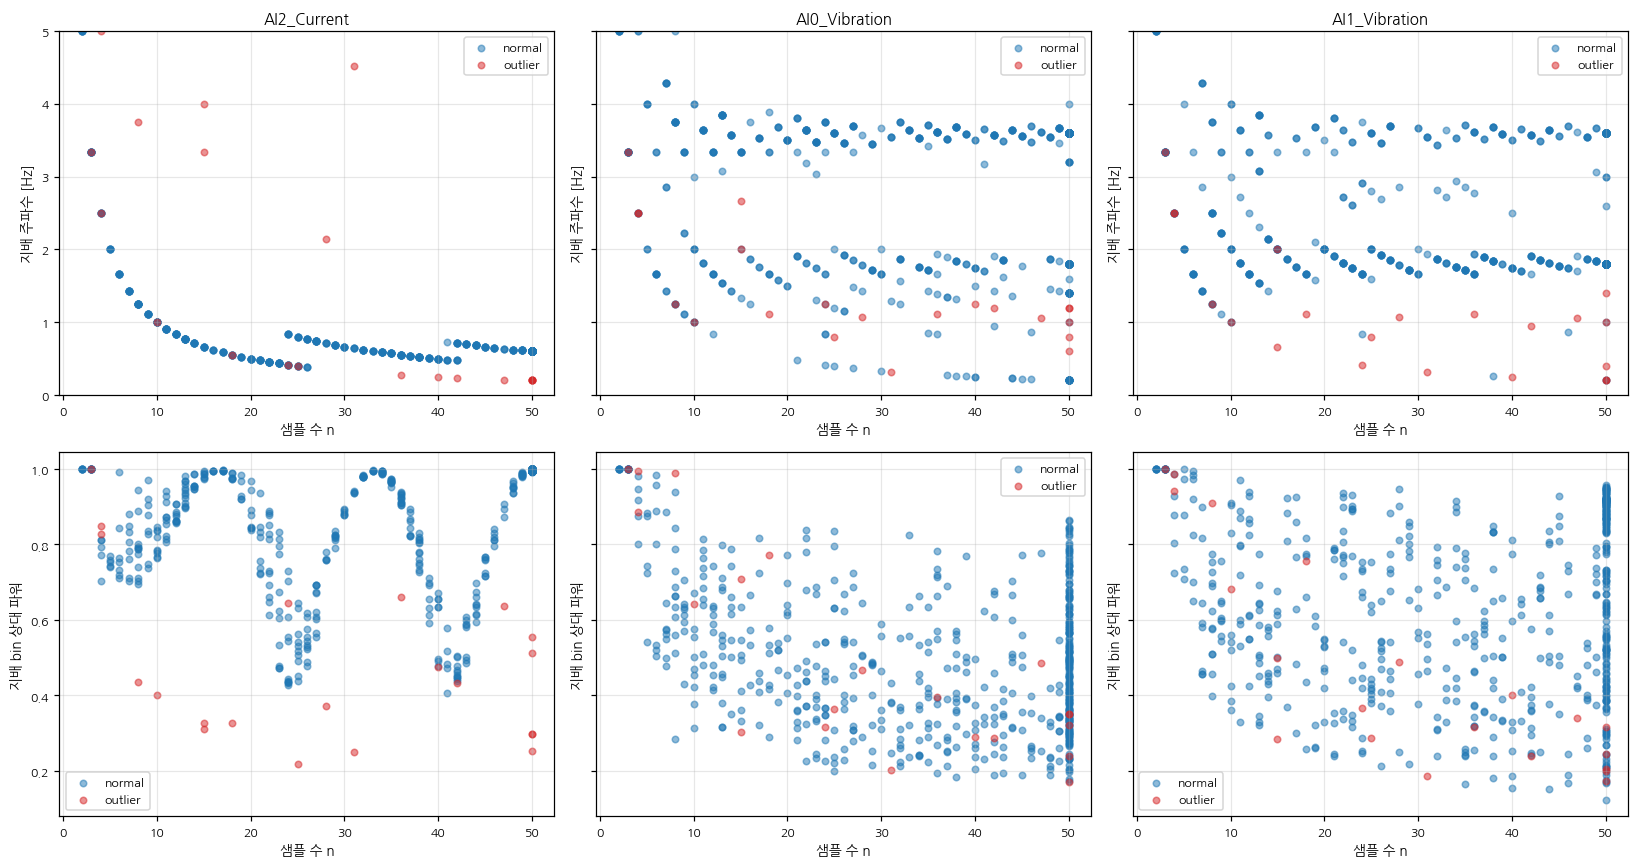

길이별 주파수·해상도 요약
길이별 대역 상대 파워 (유효 건수와 평균)


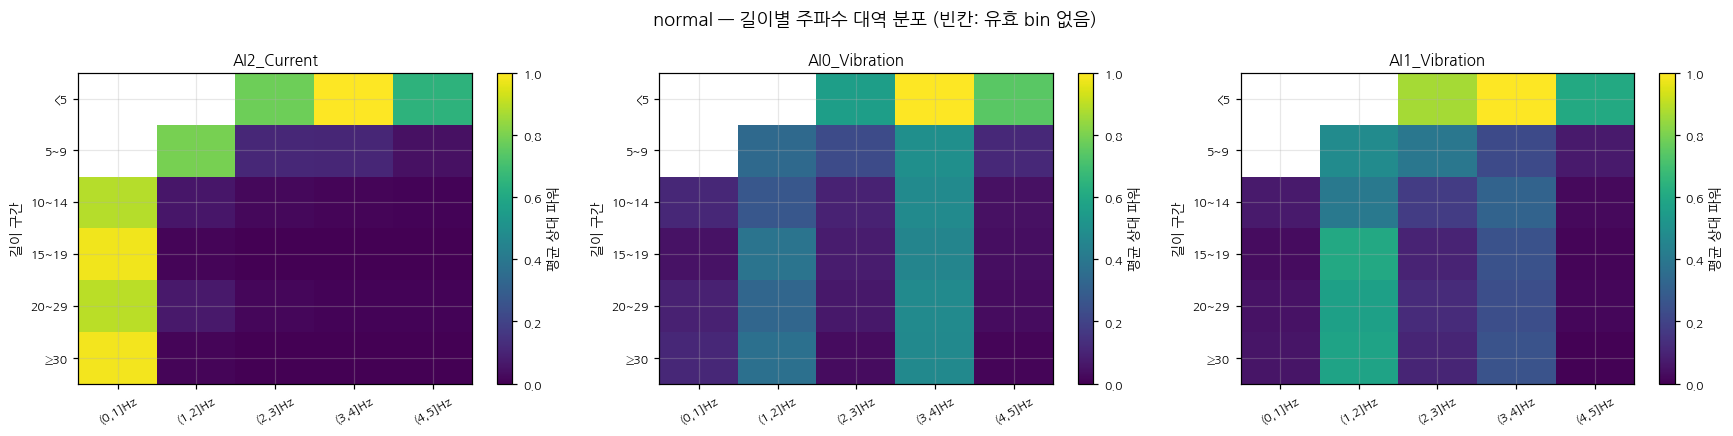

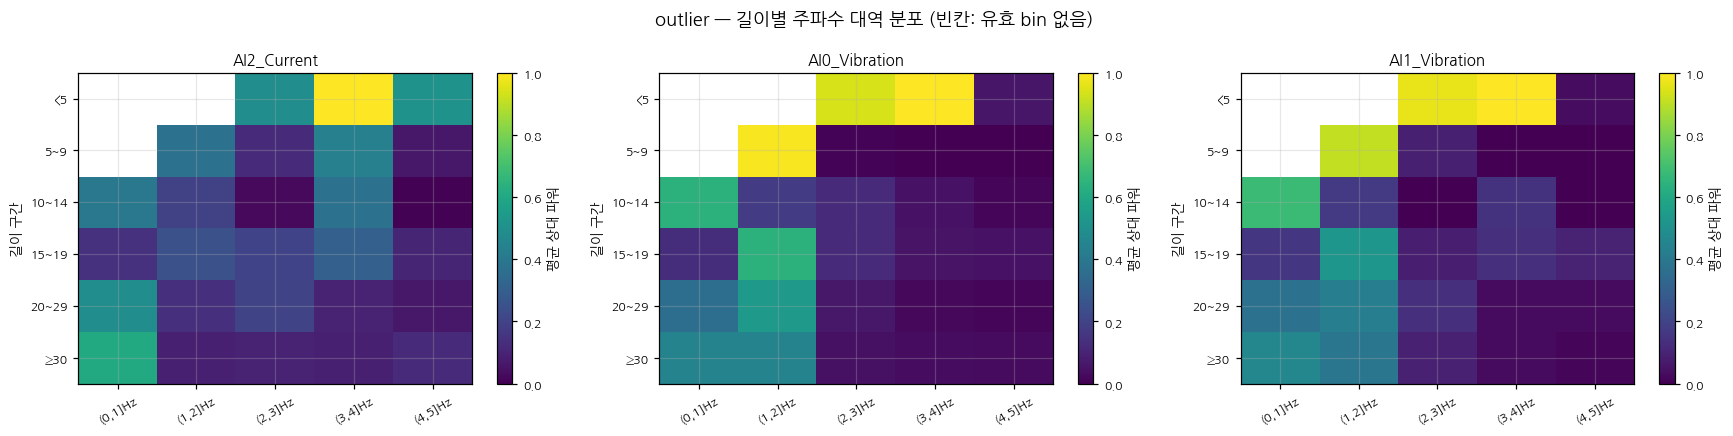

In [8]:
fig, axes = plt.subplots(2,3,figsize=(15,8),sharey="row")
for j, channel in enumerate(FFT_CHANNELS):
    for label in ["normal","outlier"]:
        sub=FFT_SEG[(FFT_SEG.channel==channel)&(FFT_SEG.label==label)]
        axes[0,j].scatter(sub.n,sub.peak_hz,s=18,alpha=.5,color=COLOR[label],label=label)
        axes[1,j].scatter(sub.n,sub.peak_share,s=18,alpha=.5,color=COLOR[label],label=label)
    axes[0,j].set_title(channel); axes[0,j].set_ylim(0,5)
    axes[0,j].set_ylabel("지배 주파수 [Hz]"); axes[1,j].set_ylabel("지배 bin 상대 파워")
    for ax in axes[:,j]: ax.set_xlabel("샘플 수 n"); ax.legend()
plt.tight_layout(); plt.show()
band_columns=[f"({lo},{hi}]Hz" for lo,hi in FFT_BANDS]
print("길이별 주파수·해상도 요약")
display_table(FFT_SEG.groupby(["label","channel","length_bin"],observed=True)[
    ["n","df_hz","peak_hz","peak_share"]].agg(["count","median"]).round(3))
print("길이별 대역 상대 파워 (유효 건수와 평균)")
display_table(FFT_SEG.groupby(["label","channel","length_bin"],observed=True)[band_columns].agg(["count","mean"]).round(3))
for label in ["normal","outlier"]:
    fig,axes=plt.subplots(1,3,figsize=(16,4))
    for ax,channel in zip(axes,FFT_CHANNELS):
        sub=FFT_SEG[(FFT_SEG.label==label)&(FFT_SEG.channel==channel)]
        matrix=sub.groupby("length_bin",observed=False)[band_columns].mean().reindex(LENGTH_LABELS)
        plot=ax.imshow(np.ma.masked_invalid(matrix.to_numpy()),aspect="auto",vmin=0,vmax=1,cmap="viridis")
        ax.set_xticks(range(5),band_columns,rotation=30); ax.set_yticks(range(6),LENGTH_LABELS)
        ax.set_title(channel); ax.set_ylabel("길이 구간")
        fig.colorbar(plot,ax=ax,label="평균 상대 파워")
    fig.suptitle(f"{label} — 길이별 주파수 대역 분포 (빈칸: 유효 bin 없음)")
    plt.tight_layout(); plt.show()


### 2-3. 대표 원시 파형과 FFT

출력이 과도해지지 않도록 10~14와 30 이상 길이에서 각 파일의 가운데 세그먼트를 비교한다.
전체 길이의 주파수 구조는 앞의 시간·길이별 그래프에서 확인한다.
단측 파워 합은 평균 제거 신호의 RMS²이며, 상대 파워는 비DC 전체 파워에 대한 비율이다.


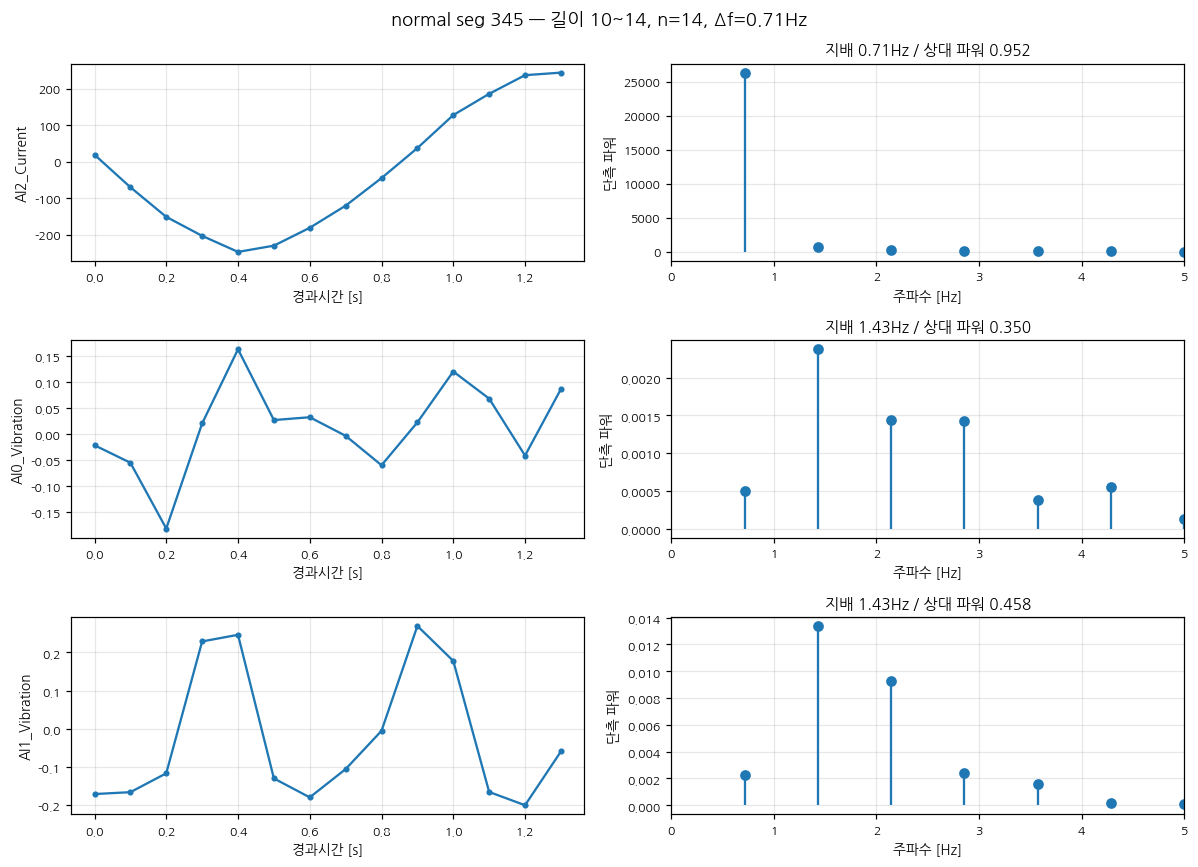

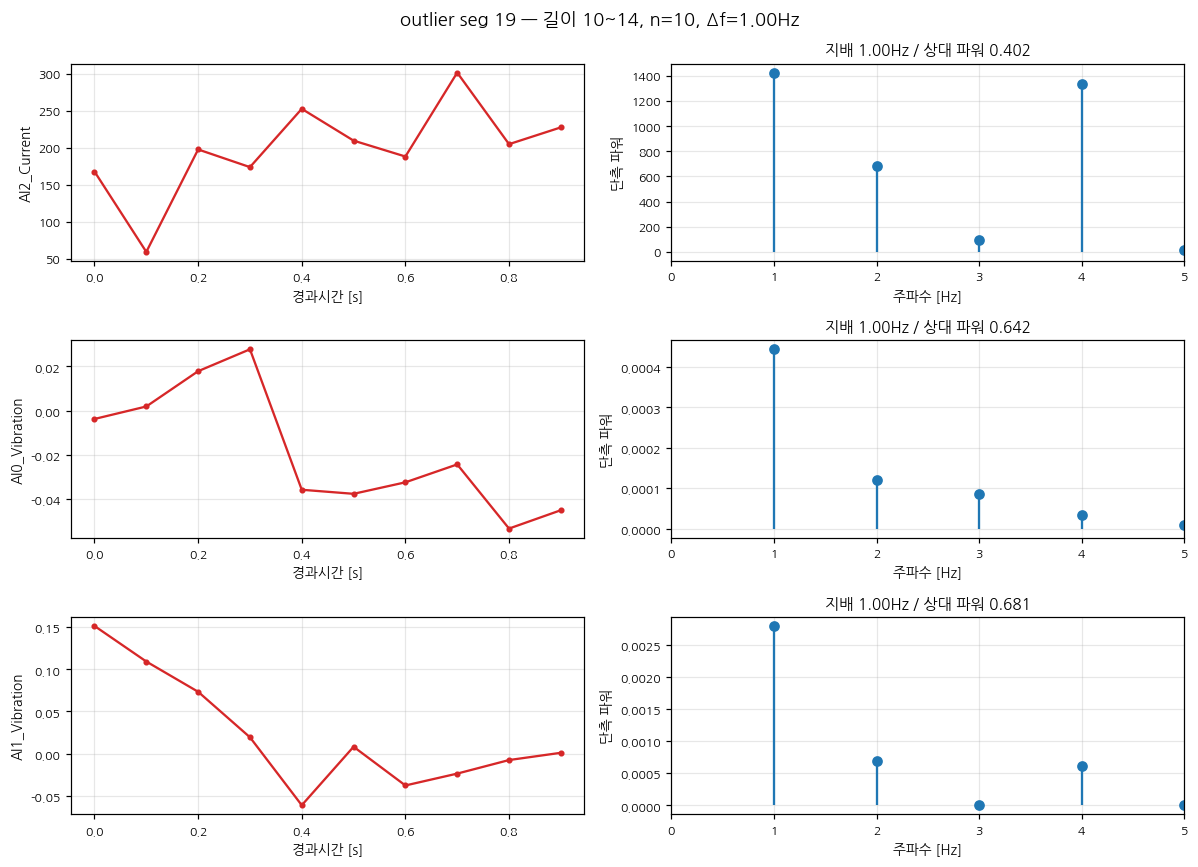

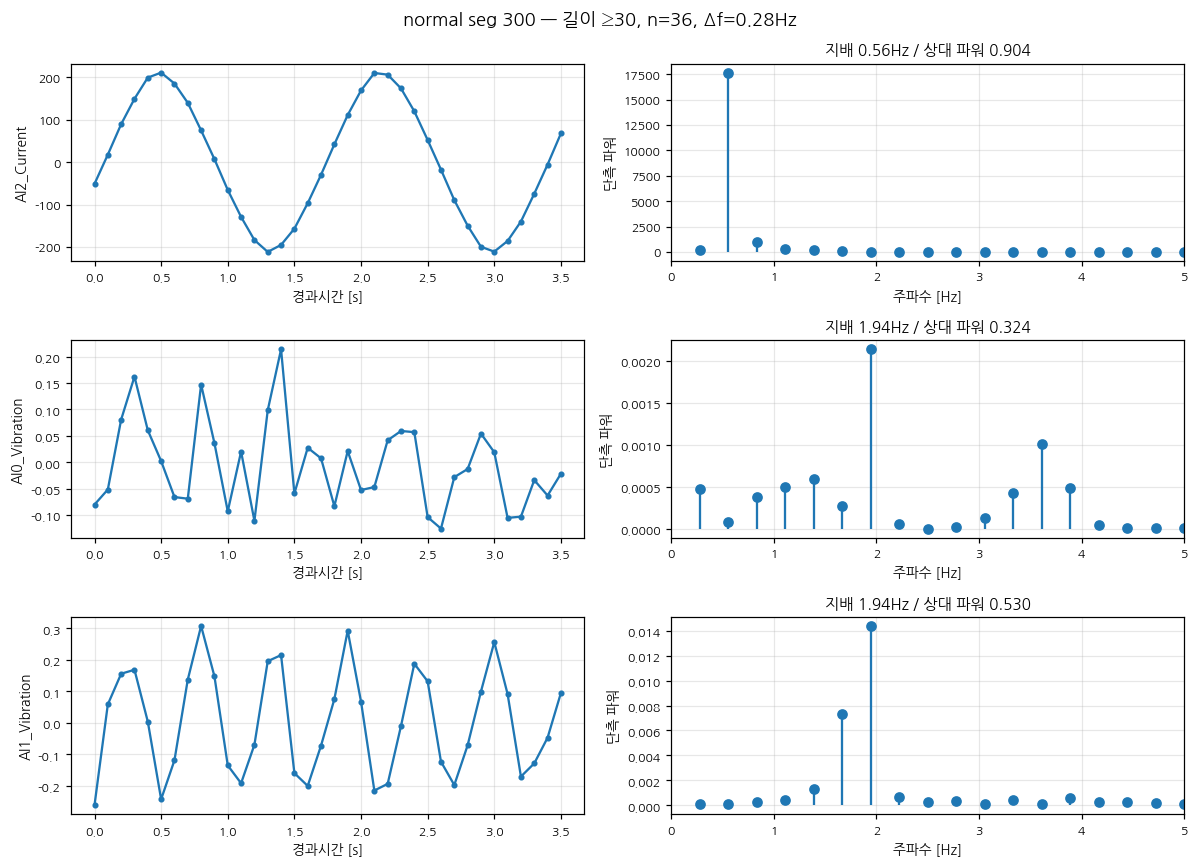

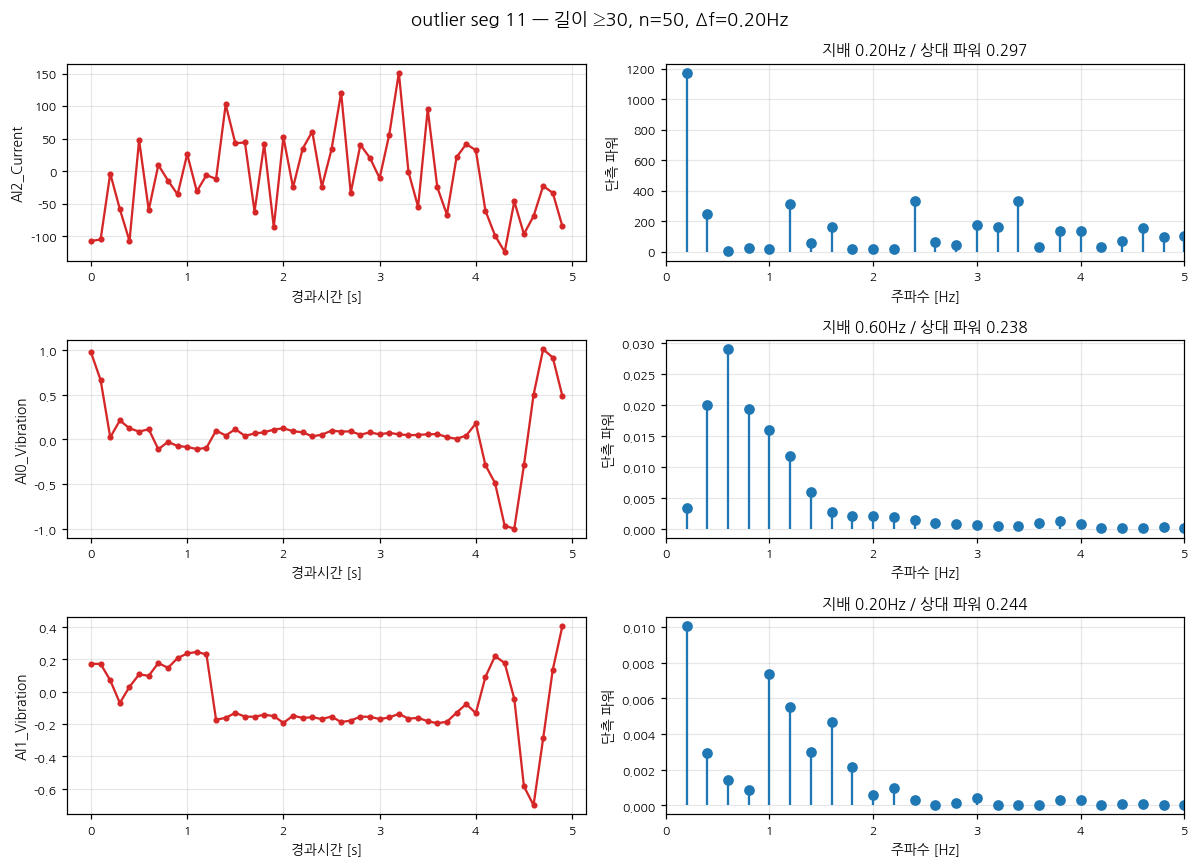

In [9]:
for length in ["10~14", "≥30"]:
    for label in ["normal","outlier"]:
        sub=F[(F.label==label)&(F.length_bin==length)].sort_values("t_start")
        if sub.empty: continue
        row=sub.iloc[len(sub)//2]; sid=int(row.seg_id)
        g=SEG[label][SEG[label].seg_id==sid]
        fig,axes=plt.subplots(3,2,figsize=(11,8))
        for i,channel in enumerate(FFT_CHANNELS):
            axes[i,0].plot((g.TimeStamp-g.TimeStamp.iloc[0]).dt.total_seconds(),g[channel],"o-",ms=3,color=COLOR[label])
            axes[i,0].set_ylabel(channel); axes[i,0].set_xlabel("経過時間 [s]".replace("経過時間","경과시간"))
            bins=FFT[(FFT.label==label)&(FFT.seg_id==sid)&(FFT.channel==channel)]
            if not bins.empty:
                axes[i,1].stem(bins.frequency_hz,bins.power,basefmt=" ")
            else:
                axes[i,1].text(.5,.5,"FFT計算不可 (n=1)".replace("計算不可","계산 불가"),transform=axes[i,1].transAxes,ha="center")
            axes[i,1].set_xlim(0,5);axes[i,1].set_xlabel("주파수 [Hz]");axes[i,1].set_ylabel("단측 파워")
            info=FFT_SEG[(FFT_SEG.label==label)&(FFT_SEG.seg_id==sid)&(FFT_SEG.channel==channel)].iloc[0]
            axes[i,1].set_title(f"지배 {info.peak_hz:.2f}Hz / 상대 파워 {info.peak_share:.3f}")
        fig.suptitle(f"{label} seg {sid} — 길이 {length}, n={len(g)}, Δf={FS/len(g):.2f}Hz")
        plt.tight_layout();plt.show()


## 3. 정상 전류의 공통 주기 기준

정상 시간순 앞 70% 중 n≥30 세그먼트에서 주기 0.9~2.2초 범위의 사인파를 적합한다.
FFT bin에 제한하지 않고 연속 주파수를 탐색하여 주파수 중앙값을 공통 기준으로 사용한다.
기준을 추정할 때만 주파수를 조정하며, 아래 비교에서는 모든 세그먼트의 주파수를 고정한다.
현재 기준은 약 **0.6000Hz / 1.6666초**다. 실제 교류 전원 주파수를 복원한 값이 아니라
10Hz 데이터에서 관측되는 정상 기준 파형의 주기다.


In [10]:
from scipy.optimize import minimize_scalar

def fit_current_sine(g, frequency_bounds=None, fixed_frequency=None):
    x = g.AI2_Current.to_numpy(dtype=float)
    t = (g.TimeStamp - g.TimeStamp.iloc[0]).dt.total_seconds().to_numpy()
    def solve(freq):
        design = np.column_stack([np.cos(2*np.pi*freq*t), np.sin(2*np.pi*freq*t), np.ones(len(t))])
        coef, *_ = np.linalg.lstsq(design, x, rcond=None)
        pred = design @ coef
        return np.sum((x-pred)**2), coef, pred
    if fixed_frequency is not None:
        freq = fixed_frequency
    else:
        lo, hi = frequency_bounds
        grid = np.linspace(lo, hi, 401)
        errors = np.array([solve(freq)[0] for freq in grid])
        best = int(errors.argmin())
        left, right = grid[max(0,best-1)], grid[min(len(grid)-1,best+1)]
        refined = minimize_scalar(lambda f: solve(f)[0], bounds=(left,right), method="bounded")
        candidates = [grid[best], refined.x, lo, hi]
        freq = min(candidates, key=lambda f: solve(f)[0])
    ss, coef, pred = solve(freq)
    total = np.sum((x-x.mean())**2)
    return {"frequency_hz": freq, "period_s": 1/freq,
            "amplitude": np.hypot(coef[0],coef[1]), "offset": coef[2],
            "rmse": np.sqrt(ss/len(x)), "nrmse": np.sqrt(ss/total) if total>0 else np.nan,
            "r2": 1-ss/total if total>0 else np.nan, "pred": pred}

normal_time = F[F.label=="normal"].sort_values("t_start")
sine_split = normal_time.t_start.quantile(.70)
reference = normal_time[(normal_time.t_start<sine_split)&(normal_time.n>=30)]
broad_bounds = (1/2.2, 1/.9)
reference_rows = []
for row in reference.itertuples():
    g=SEG["normal"][SEG["normal"].seg_id==row.seg_id]
    fit=fit_current_sine(g, frequency_bounds=broad_bounds)
    reference_rows.append({"seg_id":row.seg_id, "n":row.n,
                           **{key:value for key,value in fit.items() if key!="pred"}})
SINE_REF=pd.DataFrame(reference_rows)
f_reference=SINE_REF.frequency_hz.median()
f_lower,f_upper=SINE_REF.frequency_hz.quantile([.05,.95]).to_numpy()
if f_upper-f_lower<1e-6:
    f_lower,f_upper=f_reference-1e-6,f_reference+1e-6
print(f"基準 normal train n≥30: {len(SINE_REF)}個".replace("基準","기준").replace("個","개"))
print(f"공통 주파수 {f_reference:.4f}Hz / 주기 {1/f_reference:.4f}s")
print(f"정상 기준 주파수 5~95% 범위 {f_lower:.4f}~{f_upper:.4f}Hz")
print(f"기준 세그먼트 적합 R² 중앙값 {SINE_REF.r2.median():.4f}, 최솟값 {SINE_REF.r2.min():.4f}")



기준 normal train n≥30: 249개
공통 주파수 0.6000Hz / 주기 1.6666s
정상 기준 주파수 5~95% 범위 0.5973~0.6028Hz
기준 세그먼트 적합 R² 중앙값 0.9972, 최솟값 0.9943


## 4. 정상 기준 중심·진폭을 고정한 전류 파형과 비교

기존 적합은 세그먼트마다 진폭·위상·중심값을 조정했다. 짧은 조각에서 자유로운 중심 이동으로
잔차가 작아지는지 확인하기 위해, 긴 정상 train의 사인 적합에서 중심값·진폭 중앙값을 추정한다.
짧은 세그먼트의 표본 평균을 빼지는 않는다. 부분 주기의 평균은 파형의 실제 중심과 다르다.

모든 모델에서 주기는 기존 공통 기준으로 고정한다.

| 모델 | 세그먼트마다 허용하는 값 |
|---|---|
| 기존 자유 적합 | 진폭·위상·중심값 |
| 정상 중심 고정 | 진폭·위상 (중심은 정상 train 기준) |
| 영점 고정 | 진폭·위상 (중심 0) |
| 정상 기준 파형 | 위상만 (진폭·중심 모두 정상 train 기준) |

위상은 취득 시작 위치가 다르므로 조정한다. 정상 진폭도 부하에 따라 달라지므로,
진폭까지 고정한 모델의 큰 잔차는 파형 왜곡과 진폭 차이를 함께 반영한다.
기준값은 정상 train n≥30에서만 구하며 다른 세그먼트를 보고 다시 정하지 않는다.


정상 기준: 주기 1.6666s, 중심 0.5489, 진폭 158.3520
정상 train 중심값 5/50/95%: {0.05: -0.1084, 0.5: 0.5489, 0.95: 1.1825}
정상 train 진폭 5/50/95%: {0.05: 114.5879, 0.5: 158.352, 0.95: 250.8284}


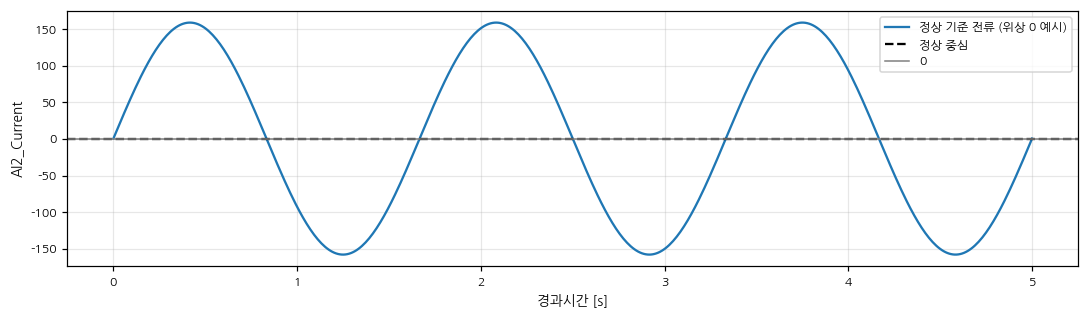

길이별 비교는 CENTER_SUMMARY 에 저장


In [11]:
from scipy.optimize import minimize_scalar

# 기존 SINE_REF는 주파수도 조정했으므로 공통 주기 고정 상태에서 기준을 다시 계산한다.
center_reference_rows = []
for row in reference.itertuples():
    g = SEG["normal"].loc[SEG["normal"].seg_id == row.seg_id]
    fit = fit_current_sine(g, fixed_frequency=f_reference)
    center_reference_rows.append({"seg_id": row.seg_id, "offset": fit["offset"],
                                  "amplitude": fit["amplitude"]})
CENTER_REFERENCE = pd.DataFrame(center_reference_rows)
normal_center = CENTER_REFERENCE.offset.median()
normal_amplitude = CENTER_REFERENCE.amplitude.median()
print(f"정상 기준: 주기 {1/f_reference:.4f}s, 중심 {normal_center:.4f}, 진폭 {normal_amplitude:.4f}")
print("정상 train 중심값 5/50/95%:", CENTER_REFERENCE.offset.quantile([.05,.5,.95]).round(4).to_dict())
print("정상 train 진폭 5/50/95%:", CENTER_REFERENCE.amplitude.quantile([.05,.5,.95]).round(4).to_dict())

fig, ax = plt.subplots(figsize=(10,3))
reference_t = np.linspace(0, 3/f_reference, 500)
ax.plot(reference_t, normal_center + normal_amplitude*np.sin(2*np.pi*f_reference*reference_t),
        label="정상 기준 전류 (위상 0 예시)")
ax.axhline(normal_center, color="black", ls="--", label="정상 중심")
ax.axhline(0, color="gray", lw=1, label="0")
ax.set_xlabel("경과시간 [s]"); ax.set_ylabel("AI2_Current"); ax.legend()
plt.tight_layout(); plt.show()

def fit_centered_sine(g, center, amplitude=None):
    x = g.AI2_Current.to_numpy(dtype=float)
    t = (g.TimeStamp-g.TimeStamp.iloc[0]).dt.total_seconds().to_numpy()
    angle = 2*np.pi*f_reference*t
    if amplitude is None:
        design = np.column_stack([np.cos(angle), np.sin(angle)])
        coef, *_ = np.linalg.lstsq(design, x-center, rcond=None)
        pred = center + design@coef
    else:
        def loss(phase):
            pred = center + amplitude*np.sin(angle+phase)
            return np.sum((x-pred)**2)
        grid = np.linspace(-np.pi,np.pi,721)
        best = int(np.argmin([loss(phase) for phase in grid]))
        step = grid[1]-grid[0]
        phase = minimize_scalar(loss, bounds=(grid[best]-step,grid[best]+step), method="bounded").x
        pred = center + amplitude*np.sin(angle+phase)
    ss = np.sum((x-pred)**2)
    total = np.sum((x-x.mean())**2)
    return {"pred": pred, "rmse": np.sqrt(ss/len(x)),
            "nrmse": np.sqrt(ss/total) if total>0 else np.nan,
            "r2": 1-ss/total if total>0 else np.nan}

CENTER_MODELS = ["free", "normal_center", "zero_center", "normal_template"]
CENTER_LABELS = {"free":"기존 자유 적합",
                 "normal_center":"정상 중심 고정", "zero_center":"중심 0 고정",
                 "normal_template":"정상 진폭·중심 고정"}
CENTER_LABELS["free"] = "기존 자유 적합"
center_rows, CENTER_PRED = [], {}
for row in F.itertuples():
    g = SEG[row.label].loc[SEG[row.label].seg_id == row.seg_id]
    fits = {"free": fit_current_sine(g,fixed_frequency=f_reference),
            "normal_center": fit_centered_sine(g,normal_center),
            "zero_center": fit_centered_sine(g,0.0),
            "normal_template": fit_centered_sine(g,normal_center,normal_amplitude)}
    group = "outlier" if row.label=="outlier" else ("normal train" if row.t_start<sine_split else "normal test")
    for model, fit in fits.items():
        center_rows.append({"label":row.label,"group":group,"seg_id":row.seg_id,"n":row.n,
                            "t_start":row.t_start,"model":model,"rmse":fit["rmse"],
                            "nrmse":fit["nrmse"],"r2":fit["r2"]})
    CENTER_PRED[(row.label,row.seg_id)] = {model:fit["pred"] for model,fit in fits.items()}
CENTER_FIT = pd.DataFrame(center_rows)
CENTER_FIT["length_bin"] = pd.cut(CENTER_FIT.n,[0,4,6,8,11,15,20,30,np.inf],
                                  labels=["≤3","4~5","6~7","8~10","11~14","15~19","20~29","≥30"],right=False)
CENTER_SUMMARY = CENTER_FIT.groupby(["group","length_bin","model"],observed=True).agg(
    count=("seg_id","size"), median_nrmse=("nrmse","median"), median_r2=("r2","median"))
display_table(CENTER_SUMMARY.round(4))
print("길이별 비교는 CENTER_SUMMARY 에 저장")


### 4-1. 길이별 적합 결과의 읽는 법

위쪽은 각 제약의 길이별 NRMSE 산점도이고, 아래는 정상 test·outlier의 시간순 처음·중간·끝
최대 3개씩이다. 모든 모델에서 주기는 같다. 낮은 잔차는 해당 정상 사인 형태와의 유사성을 뜻한다.
중심을 자유롭게 맞추면 짧은 조각이 잘 맞기 쉬우며, 정상 중심 고정이 그 효과를 줄이는지 확인한다.
n≤3의 자유 적합과 n≤2의 중심 고정 적합은 관측점을 그대로 통과할 수 있어 판별 근거로 쓰지 않는다.
제약 모델에서는 NRMSE>1 또는 R²<0도 가능하다. 이는 평균값 예측보다 오차가 크다는 의미다.
고정 진폭 모델은 형태와 진폭 차이를 함께 평가한다.


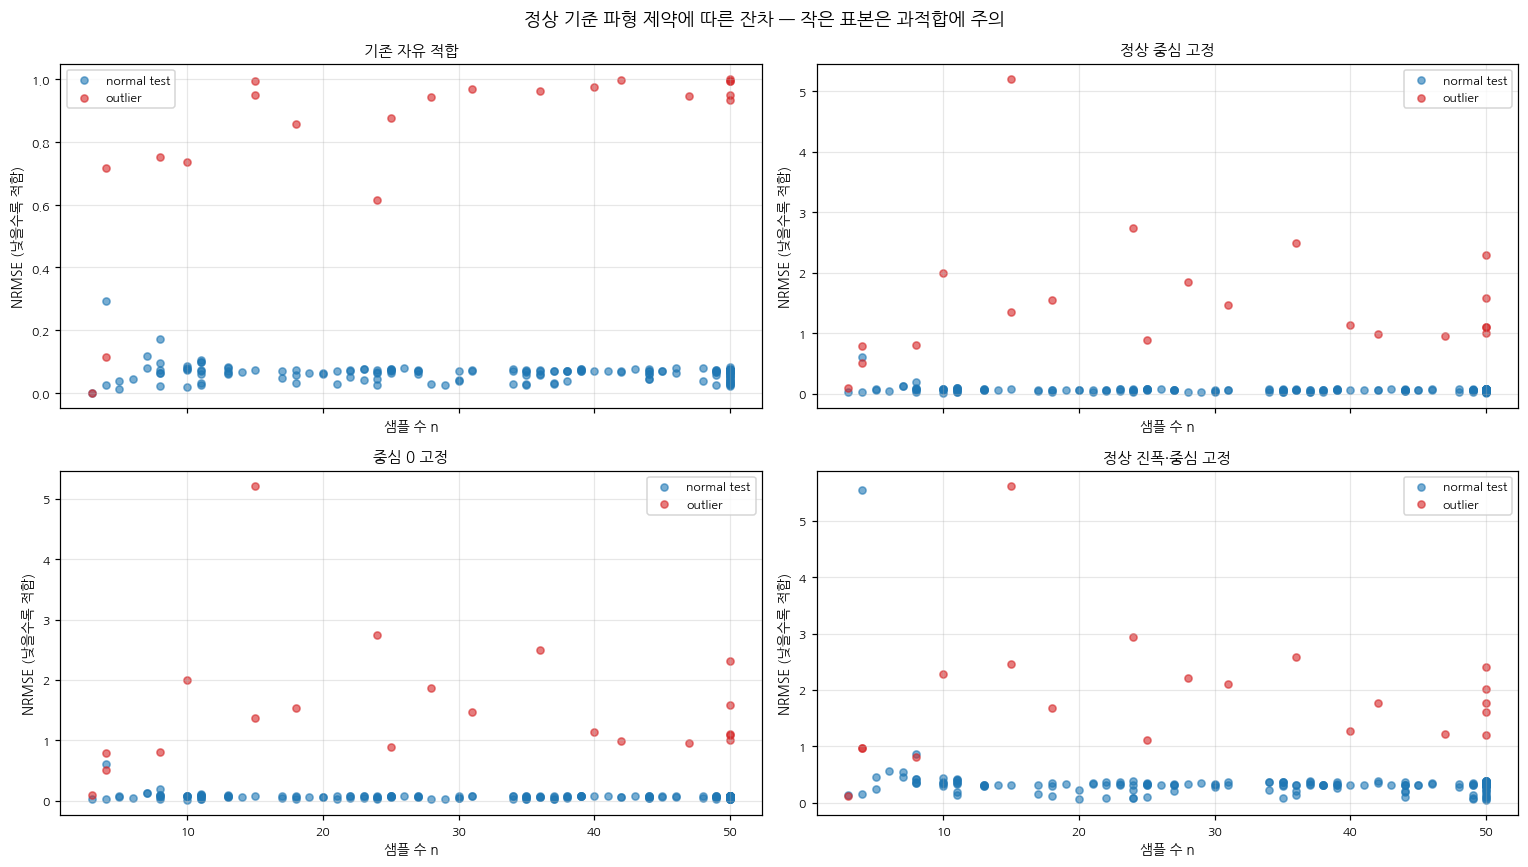

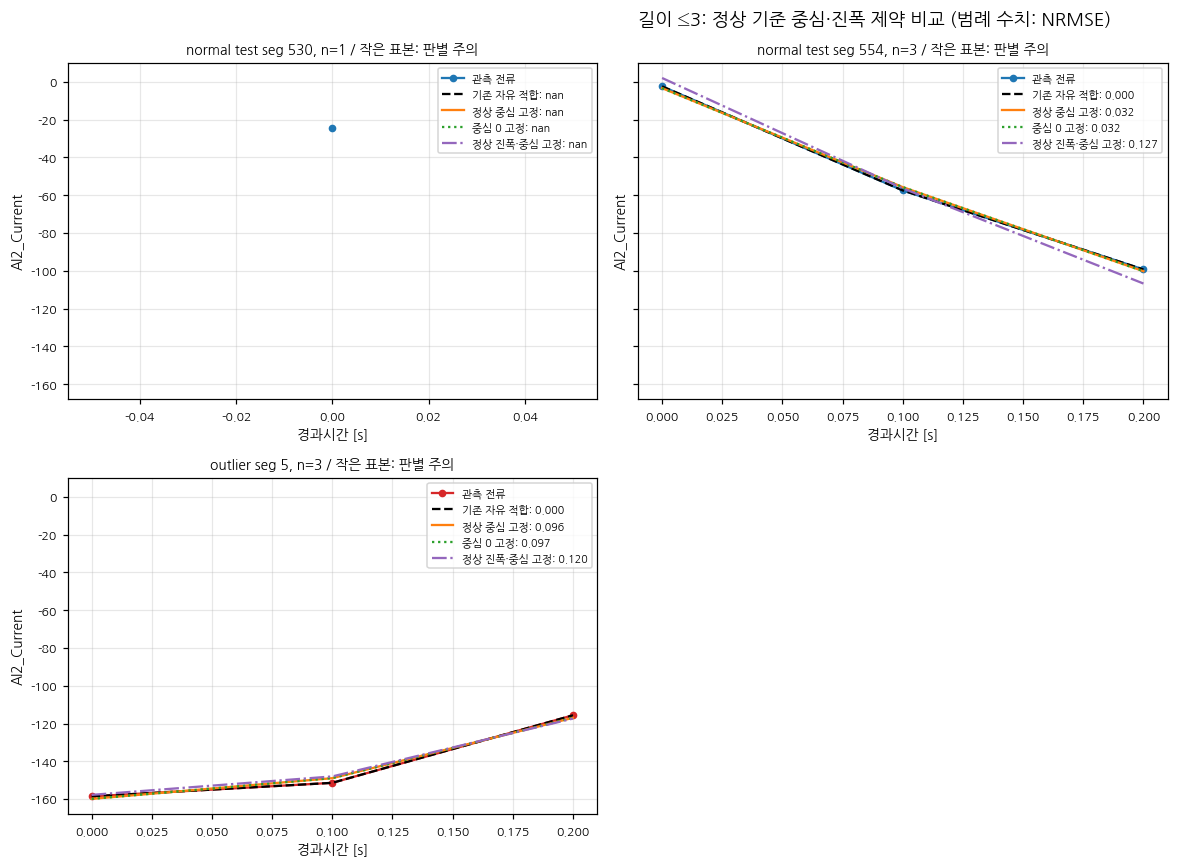

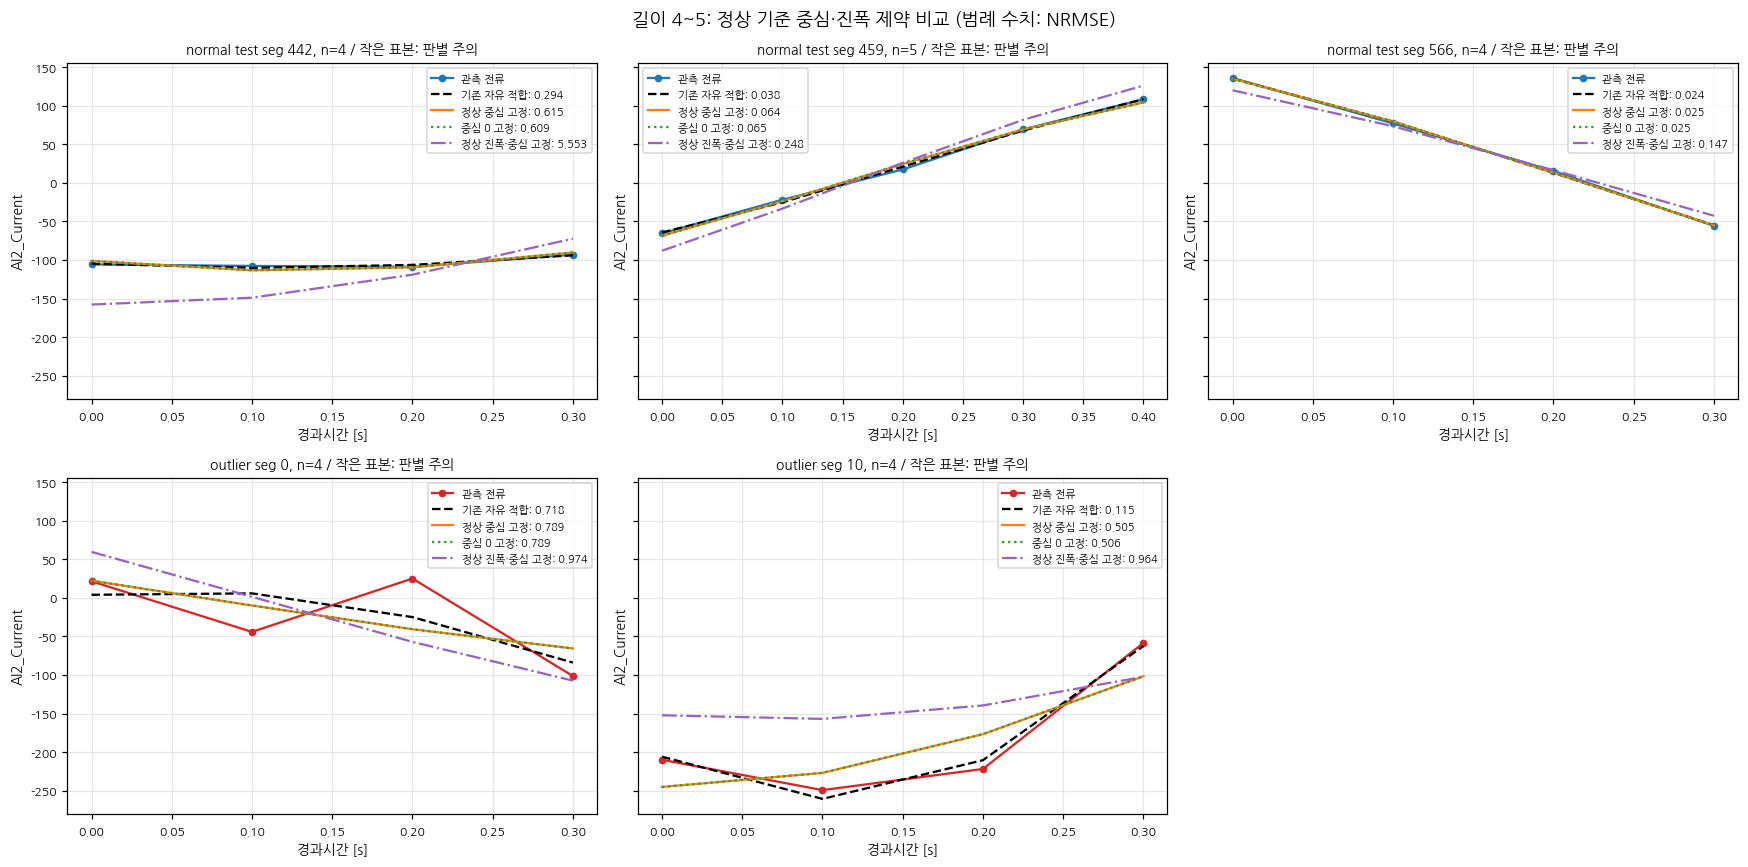

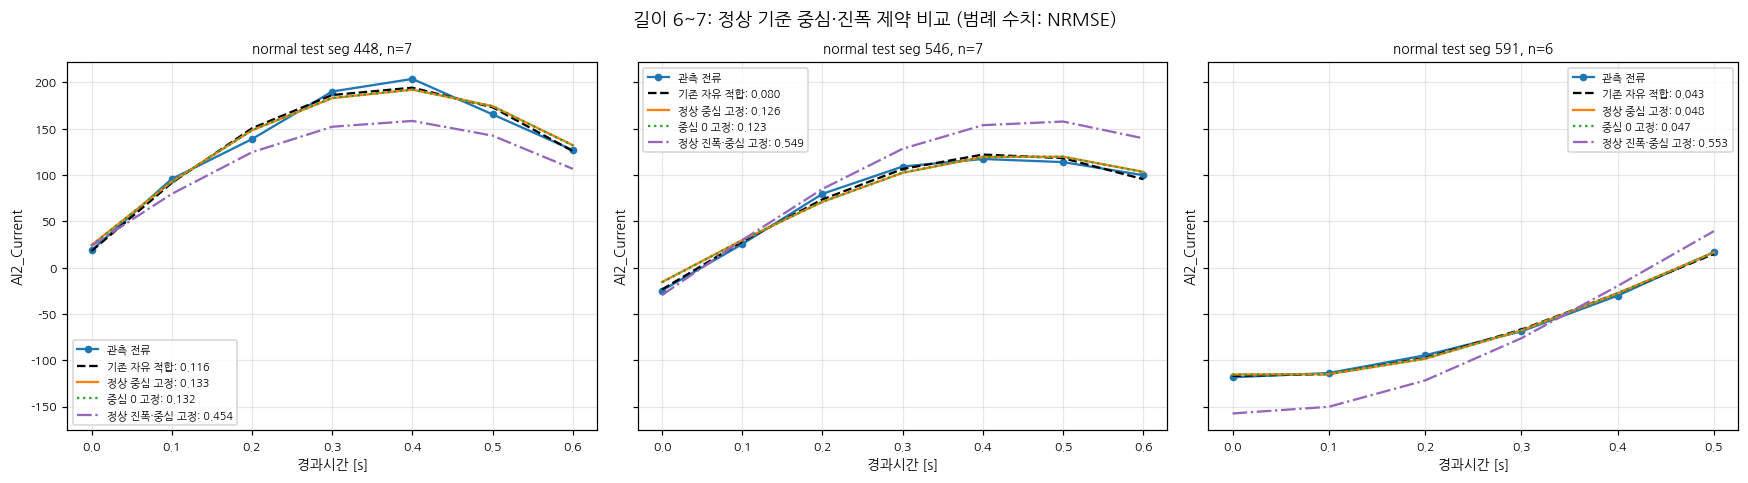

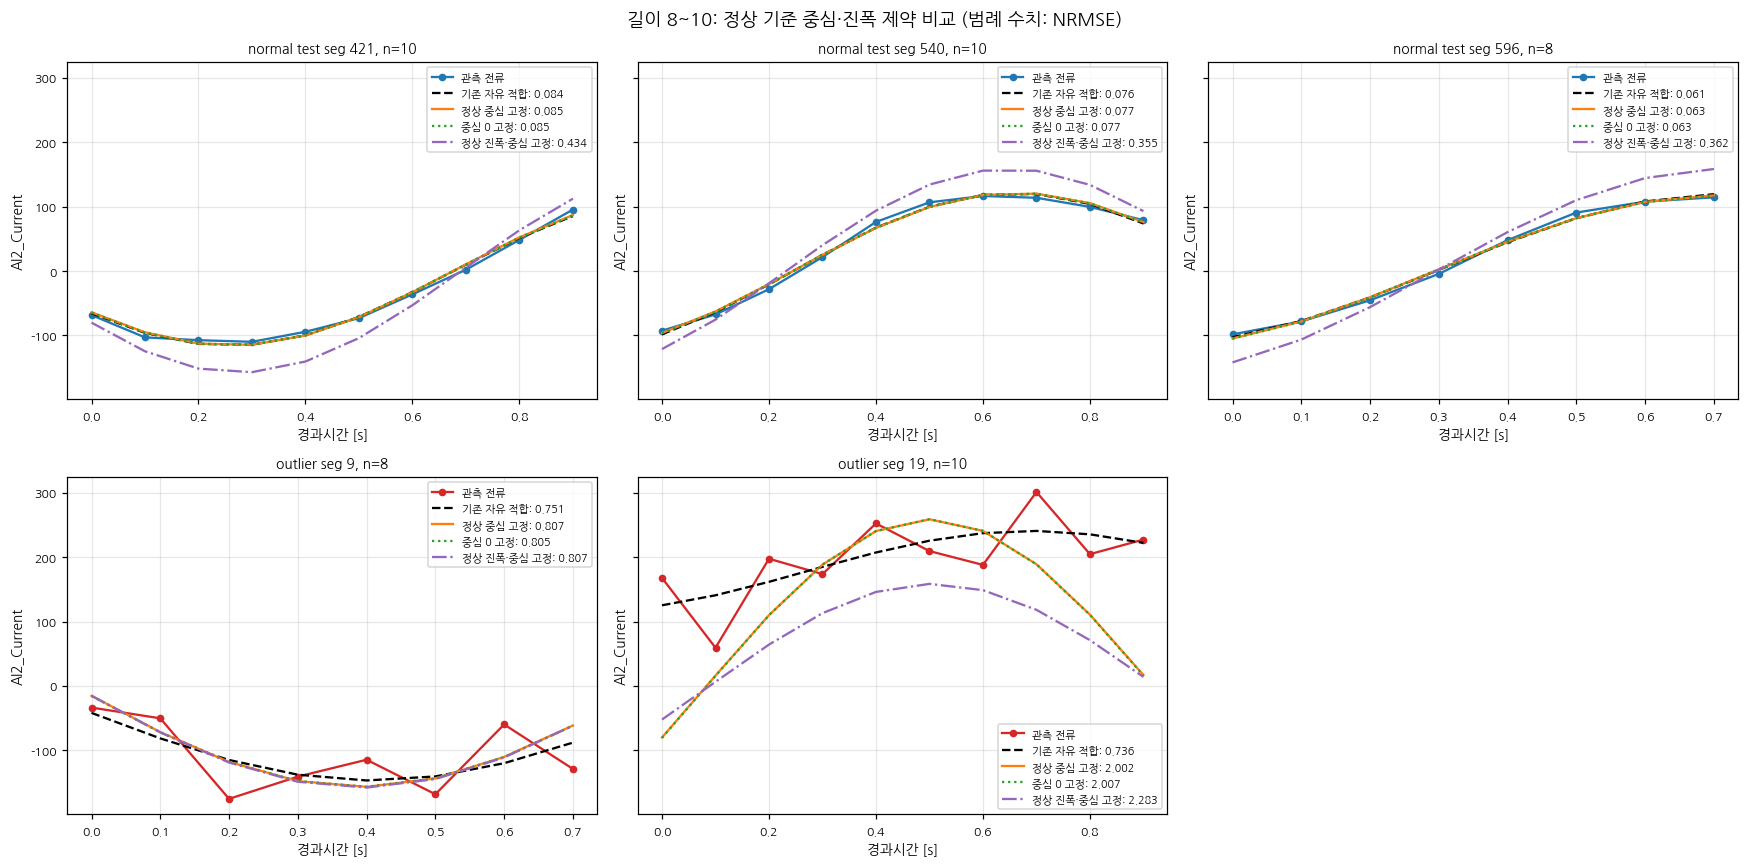

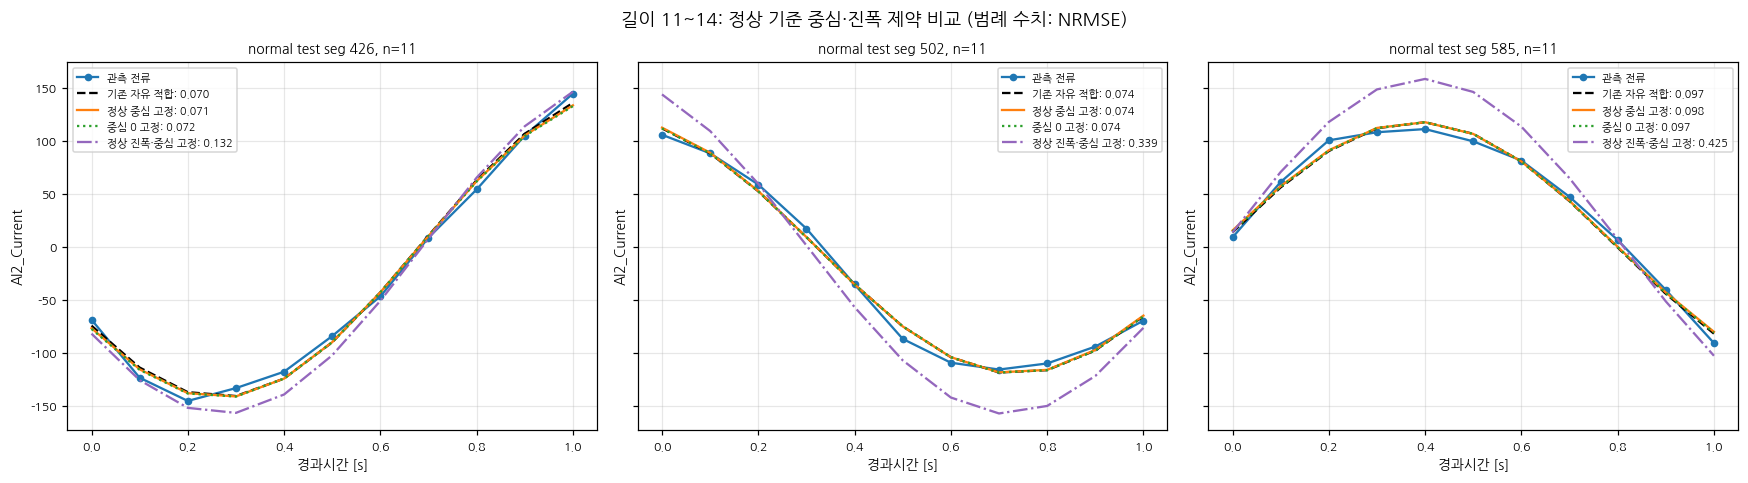

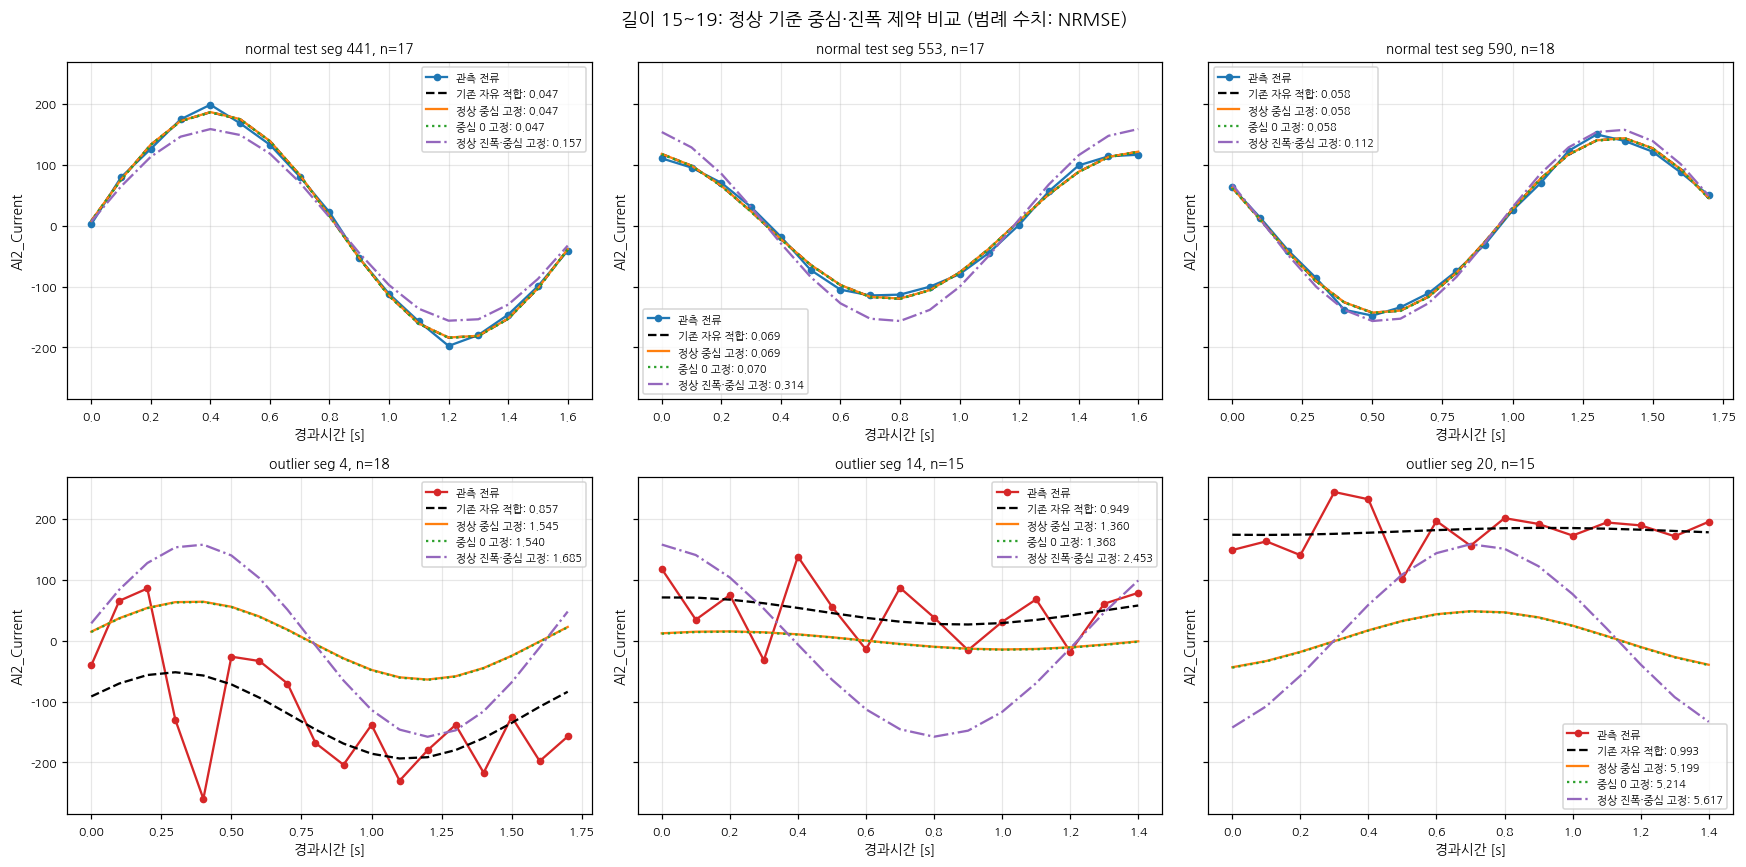

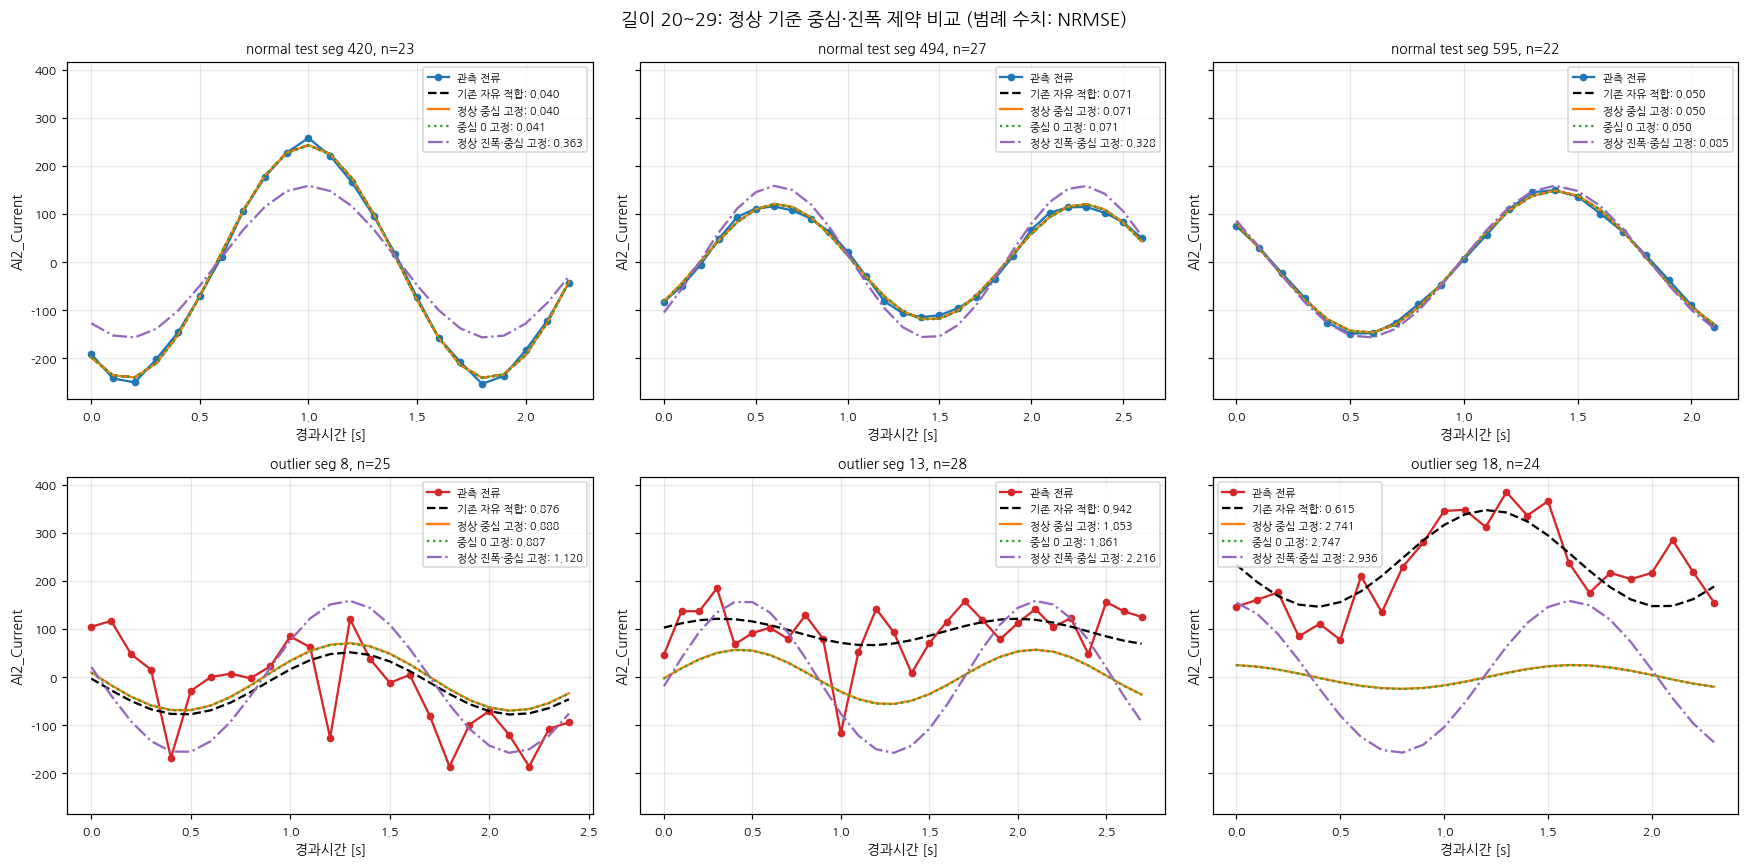

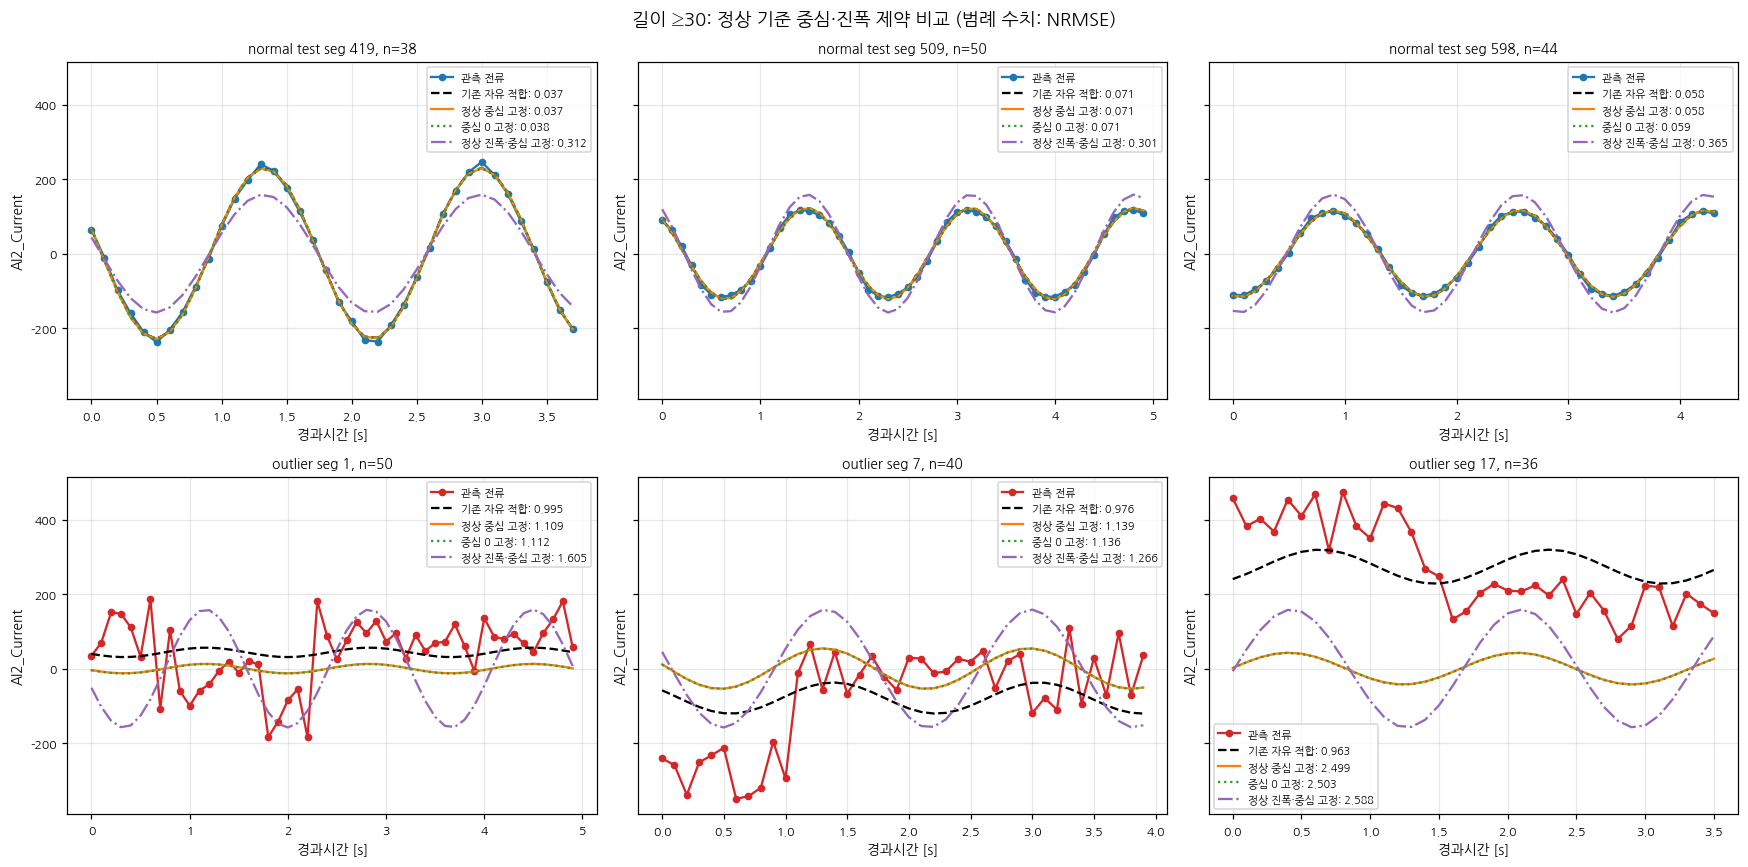

In [12]:
fig, axes = plt.subplots(2,2,figsize=(14,8),sharex=True)
for ax,model in zip(axes.flat,CENTER_MODELS):
    for group,color in [("normal test",COLOR["normal"]),("outlier",COLOR["outlier"])]:
        sub = CENTER_FIT[(CENTER_FIT.model==model)&(CENTER_FIT.group==group)]
        ax.scatter(sub.n,sub.nrmse,s=22,alpha=.6,color=color,label=group)
    ax.set_title(CENTER_LABELS[model]);ax.set_xlabel("샘플 수 n")
    ax.set_ylabel("NRMSE (낮을수록 적합)");ax.legend()
fig.suptitle("정상 기준 파형 제약에 따른 잔차 — 작은 표본은 과적합에 주의")
plt.tight_layout();plt.show()

EXAMPLE_BINS = [("≤3",1,4),("4~5",4,6),("6~7",6,8),("8~10",8,11),
                ("11~14",11,15),("15~19",15,20),("20~29",20,30),("≥30",30,np.inf)]
for name, lower, upper in EXAMPLE_BINS:
    examples = {}
    for label in ["normal", "outlier"]:
        sub = F[(F.label == label) & (F.n >= lower) & (F.n < upper)].sort_values("t_start")
        if label == "normal": sub = sub[sub.t_start >= sine_split]
        indices = np.linspace(0, len(sub)-1, min(3, len(sub)), dtype=int)
        examples[label] = sub.iloc[indices]
    selected = pd.concat(examples.values())
    if selected.empty: continue
    all_values = []
    for row in selected.itertuples():
        g = SEG[row.label].loc[SEG[row.label].seg_id == row.seg_id]
        all_values.append(g.AI2_Current.to_numpy())
        all_values.extend(CENTER_PRED[(row.label,row.seg_id)].values())
    all_values = np.concatenate(all_values)
    low, high = all_values.min(), all_values.max()
    pad = max((high-low)*.05, 1.0)
    fig, axes = plt.subplots(2,3,figsize=(16,8),sharey=True,squeeze=False)
    for i,label in enumerate(["normal","outlier"]):
        rows = list(examples[label].itertuples())
        for j,ax in enumerate(axes[i]):
            if j >= len(rows): ax.set_visible(False); continue
            row = rows[j]
            g = SEG[label].loc[SEG[label].seg_id == row.seg_id]
            t = (g.TimeStamp-g.TimeStamp.iloc[0]).dt.total_seconds()
            ax.plot(t,g.AI2_Current,"o-",ms=4,color=COLOR[label],label="観測電流".replace("観測電流","관측 전류"))
            metrics = CENTER_FIT[(CENTER_FIT.label==label)&(CENTER_FIT.seg_id==row.seg_id)].set_index("model")
            for model,style,color in [("free","--","black"),("normal_center","-","#ff7f0e"),
                                      ("zero_center",":","#2ca02c"),("normal_template","-.","#9467bd")]:
                ax.plot(t,CENTER_PRED[(label,row.seg_id)][model],style,color=color,
                        label=f"{CENTER_LABELS[model]}: {metrics.loc[model,'nrmse']:.3f}")
            group = "normal test" if label=="normal" else "outlier"
            caution = " / 小標本: 판별 주의".replace("小標本","작은 표본") if row.n<=5 else ""
            ax.set_title(f"{group} seg {row.seg_id}, n={row.n}{caution}",fontsize=9)
            ax.set_ylim(low-pad,high+pad)
            ax.set_xlabel("경과시간 [s]");ax.set_ylabel("AI2_Current");ax.legend(fontsize=7)
    fig.suptitle(f"길이 {name}: 정상 기준 중심·진폭 제약 비교 (범례 수치: NRMSE)")
    plt.tight_layout();plt.show()


### 4-2. 비교 결과와 해석

정상 train 기준 중심값은 **0.5489**, 진폭 중앙값은 **158.3520**이다.
중심값은 진폭에 비해 작으며, 정상 중심 고정과 영점 고정 결과도 유사하다.
센서 단위 및 전처리는 별도 확인 대상이며 이 값만으로 실제 DC 전류를 단정하지 않는다.

| 모델 | 정상 test NRMSE 중앙값 | outlier NRMSE 중앙값 |
|---|---:|---:|
| 기존 자유 적합 | 0.069 | 0.947 |
| 정상 중심 고정 | 0.069 | 1.139 |
| 중심 0 고정 | 0.069 | 1.136 |
| 정상 진폭·중심 고정 | 0.318 | 1.765 |

정상 중심을 고정해도 정상 파형의 적합성은 거의 유지되며 outlier 잔차는 커졌다.
기존에 잘 맞던 outlier seg10(n=4)은 NRMSE **0.115 → 0.505**, R² **0.987 → 0.745**로
변했다. 자유로운 중심 이동이 짧은 이상 조각을 잘 맞게 만들 수 있다는 구체적 사례다.
반면 진폭까지 고정하면 정상의 부하·진폭 차이도 잔차에 반영되므로 형태와 진폭의 효과를
구분해야 한다. **정상 주기·중심을 고정하고 진폭·위상만 허용한 잔차가 유망하나, 채택은 보류한다.**

중심을 고정한 모델은 평균값을 자유롭게 맞추지 않으므로 NRMSE가 1보다 크거나 R²가 음수가
될 수 있다. 이는 평균값만 사용하는 예측보다 오차가 크다는 뜻이며 계산 오류가 아니다.
짧은 표본에서는 여전히 위상·진폭만으로 잘 맞는 경우가 있을 수 있고, 중심 고정만으로
판별 문제가 모두 해소되지는 않는다. 경보 임계와 길이별 오경보·미탐률은 03에서 평가해야 한다.


## 5. 현재 판단과 다음 단계 — 상·하부 진동

**전류:** 공통 주기·정상 중심을 고정한 잔차가 유망하다. 피처 채택과 경보 임계는 아직 결정하지 않는다.
현재 데이터 내 길이별 비교이며, 다른 날짜에 대한 일반화는 검증하지 못했다.
파일 라벨 기준 차이를 설비 고장이나 조기탐지 성능으로 확정하지 않는다.

**다음은 진동 분석이다.** 앞 FFT 결과를 출발점으로 상·하부 진동을 각각 확인한다.

1. 정상/이상에서 RMS·관측 주파수 대역·주기성이 어떻게 달라지는가?
2. 시간이 지나거나 세그먼트 길이가 달라져도 차이가 유지되는가?
3. 상·하부 진동이 함께 변하는지, 특정 채널에만 변화가 나타나는가?
4. 현재 ai0_rms·env_cv·ai0_ac1을 유지하거나 보완할 지표가 있는가?

진동은 전류의 고정 사인파 가정을 그대로 적용하지 않는다. 원시 파형과 시간·길이별 분포를
확인한 뒤 피처 후보를 정하고, 이후 03에서 규칙 기반 오류율을 평가한다.


### 5-0. 하부 진동·전류 보조 지표 생성

`F`에는 `AI0_Vibration` 기반 지표만 있다. `AI1_Vibration`(하부 진동)에 같은 정의(rms, lag-1
자기상관)를 적용하고, 전류 rms와 세그먼트 내 AI0-AI1 순간상관(동일 시점 표본 간 상관,
n<5는 정의하지 않음)을 추가한다. 길이 하한을 두지 않고 전부 계산하므로, 짧은 세그먼트의
가/불안정성은 이후 절에서 길이별로 따로 확인한다.

In [13]:
def add_ai1_current_features(sdf, label):
    rows = []
    for sid, g in sdf.groupby("seg_id"):
        x0 = g["AI0_Vibration"].to_numpy(dtype=float)
        x1 = g["AI1_Vibration"].to_numpy(dtype=float)
        x2 = g["AI2_Current"].to_numpy(dtype=float)
        inst_corr = np.nan
        if len(g) >= 5 and x0.std() > 0 and x1.std() > 0:
            inst_corr = float(np.corrcoef(x0, x1)[0, 1])
        rows.append({
            "label": label, "seg_id": sid,
            "ai1_rms": float(np.sqrt((x1 ** 2).mean())),
            "ai1_ac1": float(pd.Series(x1).autocorr(1)) if len(g) > 3 else np.nan,
            "cur_rms": float(np.sqrt((x2 ** 2).mean())),
            "inst_corr": inst_corr,
        })
    return pd.DataFrame(rows)

EXTRA = pd.concat([add_ai1_current_features(SEG[k], k) for k in DFS], ignore_index=True)
F = F.merge(EXTRA, on=["label", "seg_id"])
Fn = F[F.label == "normal"].sort_values("t_start").reset_index(drop=True)
Fo = F[F.label == "outlier"].sort_values("t_start").reset_index(drop=True)
EDA_FEATURES = EDA_FEATURES + ["ai1_rms", "ai1_ac1"]
print(f"inst_corr 결측(n<5 또는 무변화): normal {F.loc[F.label=='normal','inst_corr'].isna().sum()}개, "
      f"outlier {F.loc[F.label=='outlier','inst_corr'].isna().sum()}개")
display_table(F[["label","seg_id","n","ai0_rms","ai1_rms","ai0_ac1","ai1_ac1","cur_rms","inst_corr"]].describe())

inst_corr 결측(n<5 또는 무변화): normal 29개, outlier 3개


### 5-1. RMS·지배주파수·주기성 — 상부 vs 하부

의도: 같은 정의(rms, lag-1 자기상관)를 상·하부에 동일하게 적용했을 때 분리력이 비슷한지,
그리고 앞 FFT 결과(`FFT_SEG`)에서 이미 계산해 둔 지배주파수·상대파워가 두 채널에서
어떻게 다른지 함께 본다. AUC는 Mann-Whitney 기반이며 파일 라벨 기준 분리력일 뿐
세그먼트 단위 정답은 아니다.


FFT_SEG 기준 -- 지배주파수 상대파워 (AI0 vs AI1)


peak_hz  peak_share
channel       label                       
AI0_Vibration normal     3.465       0.469
              outlier    1.190       0.364
AI1_Vibration normal     1.875       0.621
              outlier    1.000       0.340

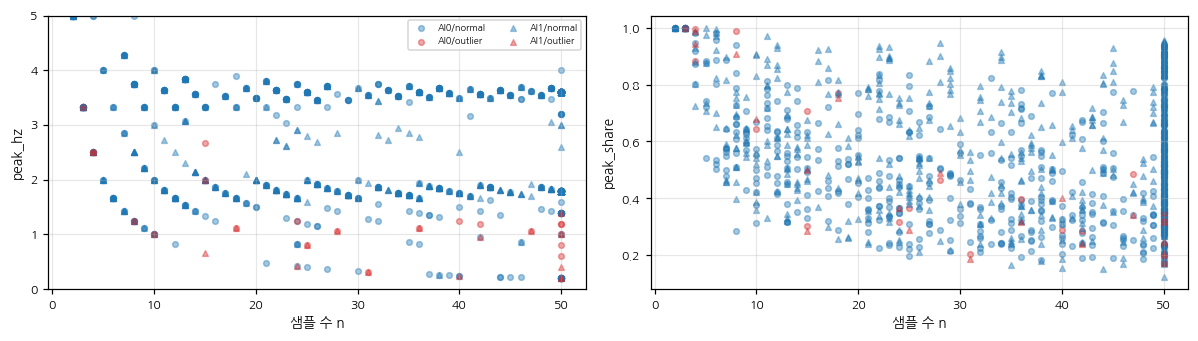

In [14]:
def auc(x, y):
    mask = ~np.isnan(x)
    x, y = x[mask], y[mask]
    n1, n0 = int(y.sum()), int((~y).sum())
    if n1 == 0 or n0 == 0: return np.nan
    r = pd.Series(x).rank().to_numpy()
    return (r[y].sum() - n1*(n1+1)/2) / (n1*n0)

y_all = (F.label == "outlier").to_numpy()
rows = []
for col in ["ai0_rms", "ai1_rms", "ai0_ac1", "ai1_ac1"]:
    rows.append({"지표": col, "normal median": F.loc[F.label=="normal", col].median(),
                 "outlier median": F.loc[F.label=="outlier", col].median(),
                 "AUC (전체, n>=1)": auc(F[col].to_numpy(), y_all)})
    sub = F[F.n >= 10]
    rows[-1]["AUC (n>=10)"] = auc(sub[col].to_numpy(), (sub.label=="outlier").to_numpy())
display_table(pd.DataFrame(rows).round(4).set_index("지표"))

print("\nFFT_SEG 기준 -- 지배주파수 상대파워 (AI0 vs AI1)")
fft_cmp = FFT_SEG[FFT_SEG.channel.isin(["AI0_Vibration","AI1_Vibration"])]
display(fft_cmp.groupby(["channel","label"])[["peak_hz","peak_share"]].median().round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
for ax, metric in zip(axes, ["peak_hz","peak_share"]):
    for ch, marker in zip(["AI0_Vibration","AI1_Vibration"], ["o","^"]):
        for label in ["normal","outlier"]:
            sub = fft_cmp[(fft_cmp.channel==ch)&(fft_cmp.label==label)]
            ax.scatter(sub.n, sub[metric], s=14, alpha=.4, marker=marker,
                      color=COLOR[label], label=f"{ch.split('_')[0]}/{label}")
    ax.set_xlabel("샘플 수 n"); ax.set_ylabel(metric)
axes[0].set_ylim(0,5); axes[0].legend(fontsize=6, ncol=2)
plt.tight_layout(); plt.show()

**결과:** `ai1_rms`는 `ai0_rms`와 거의 같은 분리력을 보인다(n>=10 기준 AUC 0.852 vs
0.849). `ai1_ac1`는 `ai0_ac1`보다 조금 낮다(0.922 vs 0.962) -- 하부가 상부를 대체할 근거는
약하다. 다만 `FFT_SEG` 지배주파수를 보면 **normal에서 AI0와 AI1의 특징주파수 자체가
다르다**(AI0 중앙값 3.47Hz, AI1 1.88Hz) -- 상부가 더 높은 주파수 성분 위주라는 뜻이다.
outlier에서는 둘 다 1~1.2Hz 근처로 모인다. 이 차이가 두 채널이 "같은 신호의 다른 세기"가
아니라 **서로 다른 진동 모드일 가능성**을 시사하며, 5-3에서 둘의 관계를 직접 본다.

### 5-2. 시간·길이에 따른 유지 여부

의도: (a) 02-1 섹션의 V자 구간에서 AI0·AI1이 같이 움직이는지, (b) rms 기반 분리력이
세그먼트 길이에 따라 얼마나 흔들리는지 확인한다. (b)는 03에서 "짧은 세그먼트가 오탐·미탐
양쪽에 영향을 준다"고 본 것을 이 노트의 길이 구간 정의로 다시 확인하는 절차다.

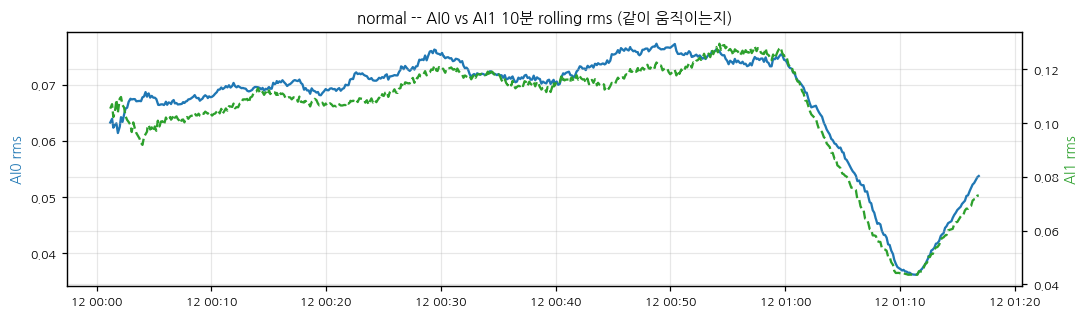

딥 밖 ai0_rms/ai1_rms 중앙값: 0.0734 0.1088
딥 안 ai0_rms/ai1_rms 중앙값: 0.0417 0.0466

길이 구간별 AUC (n>=10 안에서 세분, outlier 표본이 매우 적은 구간은 참고만)


In [15]:
dip = (Fn.t_start >= pd.Timestamp("2022-07-12 01:00:00")) & (Fn.t_start <= pd.Timestamp("2022-07-12 01:17:00"))
roll = Fn.set_index("t_start")[["ai0_rms","ai1_rms"]].rolling("600s", min_periods=10).mean()

fig, ax = plt.subplots(figsize=(10, 3))
ax2 = ax.twinx()
ax.plot(roll.index, roll.ai0_rms, color=COLOR["normal"], label="AI0 rolling")
ax2.plot(roll.index, roll.ai1_rms, color="#2ca02c", ls="--", label="AI1 rolling")
ax.set_ylabel("AI0 rms", color=COLOR["normal"]); ax2.set_ylabel("AI1 rms", color="#2ca02c")
ax.set_title("normal -- AI0 vs AI1 10분 rolling rms (같이 움직이는지)")
plt.tight_layout(); plt.show()

print("딥 밖 ai0_rms/ai1_rms 중앙값:", Fn[~dip].ai0_rms.median().round(4), Fn[~dip].ai1_rms.median().round(4))
print("딥 안 ai0_rms/ai1_rms 중앙값:", Fn[dip].ai0_rms.median().round(4), Fn[dip].ai1_rms.median().round(4))

print("\n길이 구간별 AUC (n>=10 안에서 세분, outlier 표본이 매우 적은 구간은 참고만)")
length_rows = []
for lo, hi, name in [(10,20,"10~19"), (20,30,"20~29"), (30,10**9,"30+")]:
    seg = F[(F.n>=lo)&(F.n<hi)]
    y = (seg.label=="outlier").to_numpy()
    length_rows.append({"길이구간": name, "n_normal": int((~y).sum()), "n_outlier": int(y.sum()),
                        "AUC ai0_rms": auc(seg.ai0_rms.to_numpy(), y),
                        "AUC ai1_rms": auc(seg.ai1_rms.to_numpy(), y)})
display_table(pd.DataFrame(length_rows).round(3).set_index("길이구간"))

**결과:** rolling 곡선은 AI0·AI1이 딥 구간을 포함해 거의 겹쳐 움직인다(딥 밖에서 안으로
AI0 0.073에서 0.042, AI1 0.109에서 0.047 -- 둘 다 40~57% 감소). 느린 성분은 같이 변한다.

**길이 구간별 AUC가 가장 중요한 결과다.** n=10~19에서는 AI0·AI1 rms의 AUC가 **0.52~0.54로
거의 무작위**인데, n=20~29에서 0.996~1.0, n=30 이상에서 0.92~0.95로 급등한다. 03에서
미탐지로 남은 seg19(n=10)와 seg20(n=15)가 정확히 이 "AUC가 무너지는" 길이 구간에 속한다
-- 미탐지가 피처의 한계가 아니라 **이 길이 구간에서는 rms 기반 분리력 자체가 사라진다는
더 근본적인 문제**로 재해석할 수 있다. (outlier 표본이 구간당 3~4개뿐이라 AUC 값 자체는
느슨하게 봐야 하지만, 방향(짧을수록 급격히 나빠짐)은 03의 관찰과 일치한다.)

### 5-3. 상·하부 동조성과 전류와의 관계

의도: 5-1에서 본 "다른 특징주파수"가 두 채널의 관계 자체도 다르게 만드는지 확인한다.
세그먼트 내 순간상관(같은 시점 표본 간)과, 사이클 사이 진폭(rms)의 동조를 구분해서 본다
-- 느린 성분은 5-2에서 이미 같이 움직임을 확인했으므로 여기서는 빠른 성분과 전류와의
관계에 집중한다.

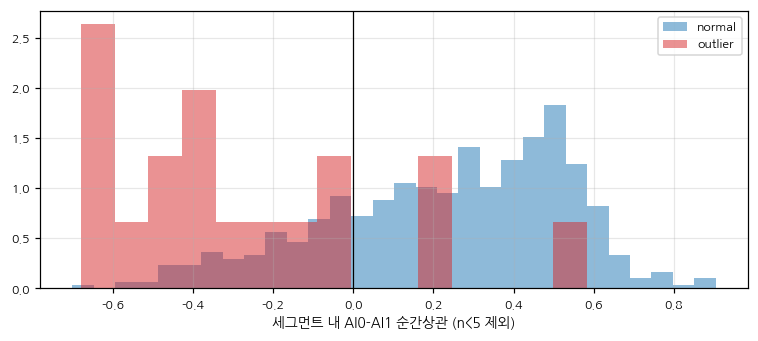

순간상관(inst_corr) 요약:
AUC(inst_corr, 낮을수록 이상 방향) = 0.8604

사이클 간 진폭(rms) 동조 -- 상관계수


In [16]:
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.hist(Fn.inst_corr.dropna(), bins=30, density=True, alpha=.5, color=COLOR["normal"], label="normal")
ax.hist(Fo.inst_corr.dropna(), bins=15, density=True, alpha=.5, color=COLOR["outlier"], label="outlier")
ax.axvline(0, color="black", lw=.8)
ax.set_xlabel("세그먼트 내 AI0-AI1 순간상관 (n<5 제외)"); ax.legend()
plt.tight_layout(); plt.show()

print("순간상관(inst_corr) 요약:")
display_table(F.groupby("label").inst_corr.describe().round(3))
print(f"AUC(inst_corr, 낮을수록 이상 방향) = {1 - auc(F.inst_corr.to_numpy(), y_all):.4f}")

print("\n사이클 간 진폭(rms) 동조 -- 상관계수")
rows = []
for a, b, name in [("ai0_rms","ai1_rms","AI0 rms - AI1 rms"),
                    ("ai0_rms","cur_rms","AI0 rms - 전류 rms"),
                    ("ai1_rms","cur_rms","AI1 rms - 전류 rms")]:
    rows.append({"관계": name, "normal": Fn[a].corr(Fn[b]), "outlier": Fo[a].corr(Fo[b])})
display_table(pd.DataFrame(rows).round(3).set_index("관계"))

**결과:** 순간상관은 **부호 자체가 바뀐다** -- normal은 평균 +0.23(상부·하부가 같은
방향으로 움직이는 경향), outlier는 평균 **-0.28**(반대 방향으로 움직이는 경향)이다.
방향을 맞춘 AUC는 0.859로 `ai1_rms` 단독(0.852)보다 낫고 `ai0_rms`(0.849)와도 다른
정보를 담고 있다 -- 진폭이 아니라 **"관계"** 자체가 바뀐다는 뜻이라 흥미롭다.

사이클 간 진폭 동조는 다른 그림을 보여준다. AI0 rms와 AI1 rms의 상관은 normal 0.675,
outlier 0.774로 **둘 다 높고 큰 차이가 없다** -- 상하부 진폭은 정상이든 이상이든 함께
움직인다. 반면 **전류와의 관계는 완전히 달라진다**: AI1 rms와 전류 rms의 상관이
normal에서 **0.902**(거의 선형)인데 outlier에서 **-0.135**로 무너진다. AI0도 같은
방향으로 무너진다(0.644에서 -0.128). 02에서 이미 진폭(p2p) 기준으로 비슷한 붕괴를
봤는데(0.749에서 0.376), rms·AI1 기준으로 다시 보면 붕괴가 더 뚜렷하다 -- **"전류와
진동이 같이 움직이는 정도" 자체가 정상/이상을 가르는 독립적인 신호**라는 근거가 쌓인다.

### 5-4. 피처 후보 종합

5-1~5-3에서 나온 후보를 03의 기존 지표(ai0_rms, purity, env_cv, ai0_ac1)와
나란히 둔다. AUC는 모두 n>=10, 방향을 맞춘 값이다.

In [17]:
sub = F[F.n >= 10].copy()
y10 = (sub.label == "outlier").to_numpy()
sub["ratio_ai1_ai0"] = sub.ai1_rms / sub.ai0_rms

candidates = [("ai0_rms", False), ("purity", True), ("env_cv", False), ("ai0_ac1", False),
              ("ai1_rms", False), ("ai1_ac1", False), ("inst_corr", True), ("ratio_ai1_ai0", True)]
rows = []
for col, invert in candidates:
    a = auc(sub[col].to_numpy(), y10)
    rows.append({"지표": col, "raw AUC": a, "방향 맞춘 AUC": (1 - a) if invert else a,
                 "출처": "03 기존" if col in ["ai0_rms","purity","env_cv","ai0_ac1"] else "02-2 신규"})
display_table(pd.DataFrame(rows).round(4).set_index("지표"))

**정리:** `ai1_rms`와 `ai1_ac1`은 기존 `ai0_rms`·`ai0_ac1`과 방향·크기가 비슷해
새로운 분리력을 크게 더하지는 않는다(상관도 0.675~0.774로 이미 강하게 묶여 있다). 반면
**`inst_corr`(상하부 순간상관, AUC 0.859)와 전류-진동 동조(AUC는 03에서 정식 평가 필요)는
진폭 계열 지표와 다른 종류의 정보**이고, 02-1에서 본 전류 형태 지표(`purity`)와도 상관이
낮을 가능성이 있어 결합 가치가 있다.

5-2의 길이구간별 AUC 붕괴(n=10~19에서 약 0.5)는 **지표를 더 추가하는 것보다 길이 보정이
먼저 필요하다**는 뜻일 수 있다 -- 짧은 세그먼트에서는 상·하부 진동 전부 분리력을 잃기
때문에, 새 지표를 얼마나 추가해도 이 구간의 근본적인 한계는 남을 가능성이 크다.

**다음 단계(03으로):** (1) `inst_corr`를 결합 점수 후보에 추가하고 n<5 결측 처리 방식을
정한다. (2) 길이 구간별(특히 10~19) 오경보·미탐률을 모든 지표에 대해 03의 규칙 기반
평가에 포함한다. (3) 전류-진동 동조 지표(상관계수 자체)를 03에서 정식으로 채점한다.
이 노트에서는 어떤 지표도 최종 채택하지 않는다.

### 5-5. 전류로 예측한 진동과의 잔차 -- 미탐지 seg19에 대한 단서

의도: 5-3에서 AI1-전류 상관이 outlier에서 무너진다고 봤다(0.902 -> -0.135). "무너짐"이
전부 같은 방향(전류 대비 진동이 더 커짐)인지, 반대 방향(전류는 그대로인데 진동만 조용해짐)도
있는지 구분한다. 03에서 rms·purity·env_cv의 OR 규칙으로도 유일하게 못 잡았던 seg19가
이 구분과 관련 있는지 확인한다. 여기서는 패턴만 본다 -- 임계·오경보율 평가는 03의 몫이다.

In [18]:
print("길이 구간별 corr(ai1_rms, cur_rms) -- normal, 길이 영향이 있는지 확인")
for lo, hi, name in [(10,20,"10~19"), (20,30,"20~29"), (30,10**9,"30+")]:
    sub = Fn[(Fn.n>=lo)&(Fn.n<hi)]
    print(f"  {name}: n={len(sub)}  pearson={sub.ai1_rms.corr(sub.cur_rms):.3f}")

sub10 = Fn[Fn.n>=10]
print(f"\nnormal n>=10 전체: pearson={sub10.ai1_rms.corr(sub10.cur_rms):.3f} "
      f"spearman={sub10.ai1_rms.corr(sub10.cur_rms, method='spearman'):.3f}")
print("-> 길이 구간 내내 0.95 이상으로 안정적이다. 02-1~5-2에서 본 다른 지표들과 달리 길이 아티팩트로 보이지 않는다.")

길이 구간별 corr(ai1_rms, cur_rms) -- normal, 길이 영향이 있는지 확인
  10~19: n=78  pearson=0.955
  20~29: n=92  pearson=0.963
  30+: n=360  pearson=0.971

normal n>=10 전체: pearson=0.967 spearman=0.865
-> 길이 구간 내내 0.95 이상으로 안정적이다. 02-1~5-2에서 본 다른 지표들과 달리 길이 아티팩트로 보이지 않는다.


정상 train 적합: ai1_rms = 0.00147 x cur_rms + -0.06585  (n=365)
정상 train 잔차 최솟값(참고용) = -0.0373

outlier(n>=10) 잔차 -- 음수일수록 '전류 대비 진동이 비정상적으로 조용함'
잔차 하위 6개: [{'seg_id': 20, 'cur_vib_resid': -0.1821}, {'seg_id': 19, 'cur_vib_resid': -0.1708}, {'seg_id': 16, 'cur_vib_resid': -0.1171}, {'seg_id': 17, 'cur_vib_resid': -0.1058}, {'seg_id': 18, 'cur_vib_resid': -0.0746}, {'seg_id': 15, 'cur_vib_resid': 0.0024}]


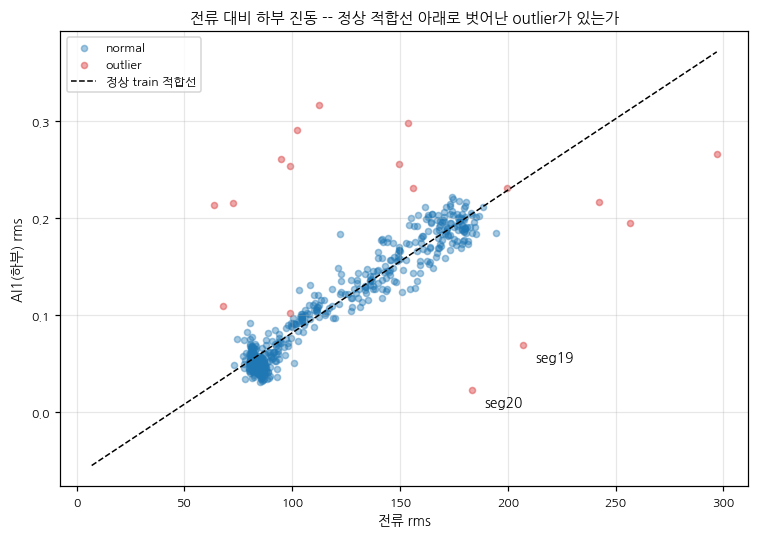

In [ ]:
# 정상 train(3절의 sine_split 기준 앞 70%, n>=10)으로 AI1 rms ~ a*전류 rms + b 적합
train = Fn[(Fn.t_start < sine_split) & (Fn.n >= 10)]
coef_a, coef_b = np.polyfit(train.cur_rms, train.ai1_rms, 1)
print(f"정상 train 적합: ai1_rms = {coef_a:.5f} x cur_rms + {coef_b:.5f}  (n={len(train)})")

for df in (F, Fn, Fo):
    df["cur_vib_resid"] = df.ai1_rms - (coef_a*df.cur_rms + coef_b)

thr_resid = train.cur_vib_resid.min() if "cur_vib_resid" in train.columns else \
    (train.ai1_rms - (coef_a*train.cur_rms+coef_b)).min()
print(f"정상 train 잔차 최솟값(참고용) = {thr_resid:.4f}")

print("\noutlier(n>=10) 잔차 -- 음수일수록 '전류 대비 진동이 비정상적으로 조용함'")
display_table(Fo.loc[Fo.n>=10, ["seg_id","n","cur_rms","ai1_rms","cur_vib_resid"]].round(4))

below = Fo.loc[Fo.n>=10].sort_values("cur_vib_resid")
print("잔차 하위 6개:", below.head(6)[["seg_id","cur_vib_resid"]].round(4).to_dict("records"))

# 비교용: AI0(상부)도 같은 방식으로 적합 (하부와 관계 강도가 다른지 나란히 확인)
coef_a0, coef_b0 = np.polyfit(train.cur_rms, train.ai0_rms, 1)
print(f"참고(상부) 정상 train 적합: ai0_rms = {coef_a0:.5f} x cur_rms + {coef_b0:.5f}")
print(f"normal train corr: AI0-전류={train.cur_rms.corr(train.ai0_rms):.3f}  "
      f"AI1-전류={train.cur_rms.corr(train.ai1_rms):.3f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
panels = [("ai0_rms", coef_a0, coef_b0, "AI0(상부)"), ("ai1_rms", coef_a, coef_b, "AI1(하부)")]
for ax, (ykey, a, b, name) in zip(axes, panels):
    for k in ["normal", "outlier"]:
        d = F[(F.label==k) & (F.n>=10)]
        ax.scatter(d.cur_rms, d[ykey], s=16, alpha=.4, color=COLOR[k], label=k)
    xs = np.linspace(F.cur_rms.min(), F.cur_rms.max(), 50)
    ax.plot(xs, a*xs+b, "k--", lw=1, label="정상 train 적합선")
    for sid in [19, 20]:
        row = Fo[Fo.seg_id==sid].iloc[0]
        ax.annotate(f"seg{sid}", (row.cur_rms, row[ykey]), xytext=(8,-10),
                   textcoords="offset points", fontsize=9, fontweight="bold")
    r = train.cur_rms.corr(train[ykey])
    ax.set_xlabel("전류 rms"); ax.set_ylabel(f"{name} rms")
    ax.set_title(f"전류 대비 {name} 진동 (normal train corr={r:.3f})")
    ax.legend()
fig.suptitle("전류 대비 상·하부 진동 비교 -- 관계 강도(corr) 차이가 seg19·20 탐지력 차이로 이어진다")
plt.tight_layout(); plt.show()

**결과:** AI1-전류 관계는 길이 구간 내내 0.95 이상(10~19: 0.955, 20~29: 0.963,
30+: 0.971)으로 안정적이다 -- 지금까지 본 다른 지표와 달리 길이 아티팩트로 보기 어렵다.
Pearson(0.967)과 Spearman(0.865)이 둘 다 높아 비선형이 아니라 거의 선형에 가깝다.

잔차를 보면 **두 가지 서로 다른 패턴이 섞여 있다.** outlier 17개(n>=10) 중 대부분(12개)은
잔차가 **양수**(전류 대비 진동이 큼 -- "시끄러움" 쪽 이상)인 반면, **seg16·17·18·19·20
다섯 개는 잔차가 음수**다. 특히 seg19·20은 산점도에서 정상 적합선보다 뚜렷이 아래,
정상 구름 바깥에 떨어져 있다 -- **AI1_rms 절대값만 보면 "정상처럼 조용"하지만, 그 시점의
전류 수준에 비해서는 비정상적으로 조용하다.**

03에서 rms·purity·env_cv OR 규칙으로 17개 중 16개(seg19 제외)를 잡았는데, 이 잔차가
음수인 세그먼트 목록에 **seg19가 포함된다.** 즉 seg19가 못 잡힌 건 신호가 정말 정상
범위 안에 있어서가 아니라, **"전류 대비 진동"이라는 관계를 안 봤기 때문일 가능성**이
있다. 다만 이 관찰은 전체 outlier 모집단(17개) 중 하나의 세그먼트에 대한 사후 확인이고,
잔차 전체의 raw AUC는 방향이 섞여 있어 낮다(단일 지표로 쓰려면 방향 분리가 필요하다).
**정식 채택·임계·오경보율 평가는 03에서 다룬다 -- 여기서는 후보로만 남긴다.**

**AI0(상부)과 나란히 보면 왜 하부 쪽 잔차가 유독 유효한지 드러난다.** normal train
corr이 AI0-전류 0.64 vs AI1-전류 0.97로, 상부는 애초에 전류와의 관계가 느슨해
"적합선"이 넓고 약하다 -- seg19·20이 그 느슨한 띠 안에 숨는다. 하부는 거의 완벽한
대각선이라 적합선 자체가 좁고 엄격해서, 거기서 벗어나는 순간(전류는 정상 범위인데
하부만 거의 0) 바로 두드러진다. 상부진동은 평소에도 전류와 느슨하게 움직이지만,
하부진동은 평소 전류에 거의 종속적으로 움직이다가 이상 시 그 종속관계 자체가
깨지는 것으로 보인다 -- 03·05(`cur_ai1_resid`가 seg19·20 전용으로 작동)와 일치한다.

### 5-6. 상하부 대칭 파형과 주파수 차이 직접 확인

의도: 두 관찰을 검증한다 -- (1) outlier에서 AI0·AI1이 상하 대칭(역상관)으로 보인다,
(2) normal에서 AI1(하부)이 AI0(상부)보다 주파수가 낮다. 5-3의 `inst_corr`, 5-1의
`FFT_SEG` 지배주파수를 재사용해 수치로 확인하고, 5-5에서 나눈 "조용함/시끄러움" 두
실패 유형과 (1)이 같이 가는지도 본다.

In [20]:
print("corr < -0.5 비율: normal=", round((Fn.inst_corr<-0.5).mean(),3),
      " outlier=", round((Fo.inst_corr<-0.5).mean(),3))

sub = Fo[Fo.n>=10].copy()
sub["failure_type"] = np.where(sub.cur_vib_resid<0, "조용함(전류 대비 진동 작음)", "시끄러움(전류 대비 진동 큼)")
display_table(sub[["seg_id","n","inst_corr","cur_vib_resid","failure_type"]].sort_values("cur_vib_resid").round(3))
print("\n실패 유형별 inst_corr 평균:")
display_table(sub.groupby("failure_type").inst_corr.agg(["mean","count"]).round(3))

corr < -0.5 비율: normal= 0.008  outlier= 0.238

실패 유형별 inst_corr 평균:


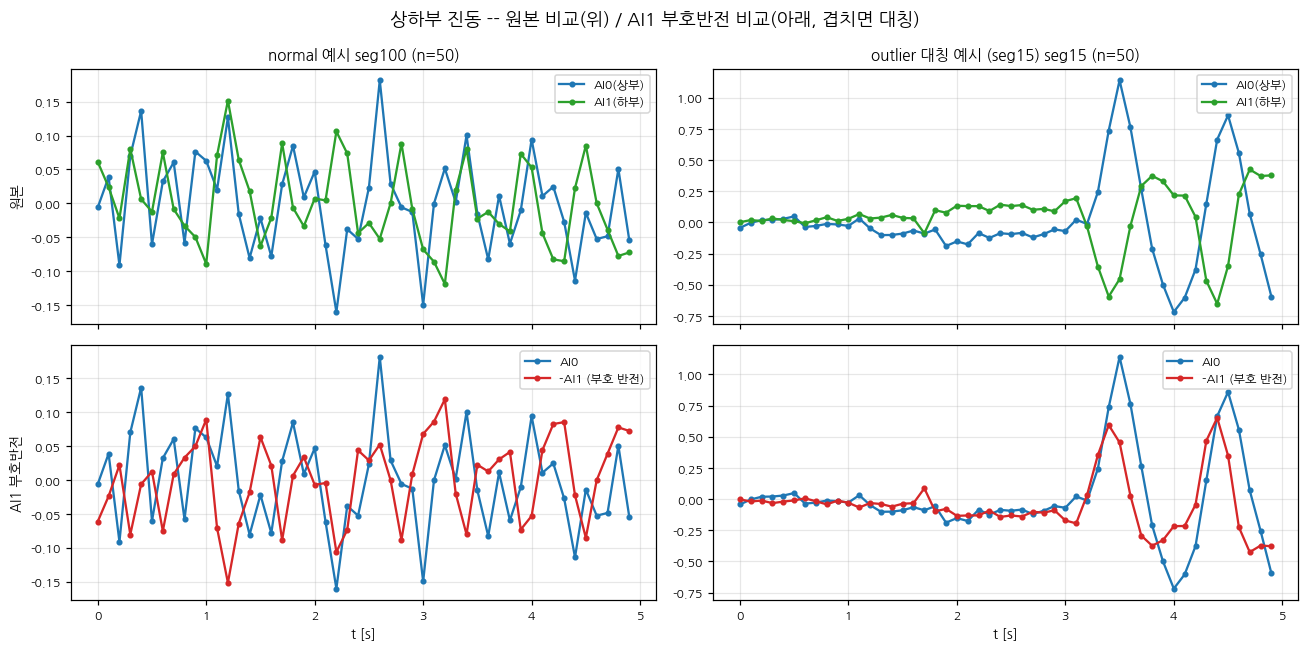

In [21]:
picks = [("normal 예시", "normal", 100), ("outlier 대칭 예시 (seg15)", "outlier", 15)]
fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex="col")
for j, (title, k, sid) in enumerate(picks):
    g = SEG[k][SEG[k].seg_id == sid]
    t = np.arange(len(g)) / FS
    axes[0, j].plot(t, g.AI0_Vibration, "o-", ms=3, color="#1f77b4", label="AI0(상부)")
    axes[0, j].plot(t, g.AI1_Vibration, "o-", ms=3, color="#2ca02c", label="AI1(하부)")
    axes[0, j].set_title(f"{title} seg{sid} (n={len(g)})"); axes[0, j].legend(fontsize=8)
    axes[1, j].plot(t, g.AI0_Vibration, "o-", ms=3, color="#1f77b4", label="AI0")
    axes[1, j].plot(t, -g.AI1_Vibration, "o-", ms=3, color="#d62728", label="-AI1 (부호 반전)")
    axes[1, j].legend(fontsize=8); axes[1, j].set_xlabel("t [s]")
axes[0, 0].set_ylabel("원본"); axes[1, 0].set_ylabel("AI1 부호반전")
fig.suptitle("상하부 진동 -- 원본 비교(위) / AI1 부호반전 비교(아래, 겹치면 대칭)")
plt.tight_layout(); plt.show()

**결과 (1) 대칭:** outlier에서 corr<-0.5인 세그먼트가 23.8%(normal은 0.8%) -- 역상관
경향이 뚜렷하다. seg15 예시는 burst 구간에서 AI0과 -AI1이 거의 겹친다(교과서적 대칭).

**다만 보편적이지 않다.** `cur_vib_resid`로 나눈 두 실패 유형의 `inst_corr` 평균이
"시끄러움" 유형 **-0.416**(12개, 뚜렷한 대칭), "조용함" 유형(seg16·17·18·19·20) **+0.067**
(거의 0, 대칭 없음)로 갈린다. **상하 대칭은 "진동이 과도하게 커지는" 실패 유형에서만
나타나고, "전류 대비 조용한" 실패 유형(seg19 포함)에는 해당하지 않는다** -- 5-5에서 나눈
두 유형이 여기서도 다른 신호를 보인다는 뜻이다.

In [22]:
fft_cmp = FFT_SEG[FFT_SEG.channel.isin(["AI0_Vibration","AI1_Vibration"])]
print("길이 구간별 지배주파수 중앙값 (AI0 vs AI1)")
display_table(fft_cmp.groupby(["label","channel","length_bin"], observed=True).peak_hz.median().unstack("channel").round(3))

print("\nrms 비교 -- 주파수는 낮아도 진폭까지 작은지 확인")
print("normal 전체 rms 중앙값: AI0=", round(Fn.ai0_rms.median(),4), " AI1=", round(Fn.ai1_rms.median(),4))
print("rms 비율(AI1/AI0) 중앙값:", round((Fn.ai1_rms/Fn.ai0_rms).median(),3), "-> AI1이 더 작지 않다")

길이 구간별 지배주파수 중앙값 (AI0 vs AI1)

rms 비교 -- 주파수는 낮아도 진폭까지 작은지 확인
normal 전체 rms 중앙값: AI0= 0.0694  AI1= 0.089
rms 비율(AI1/AI0) 중앙값: 1.377 -> AI1이 더 작지 않다


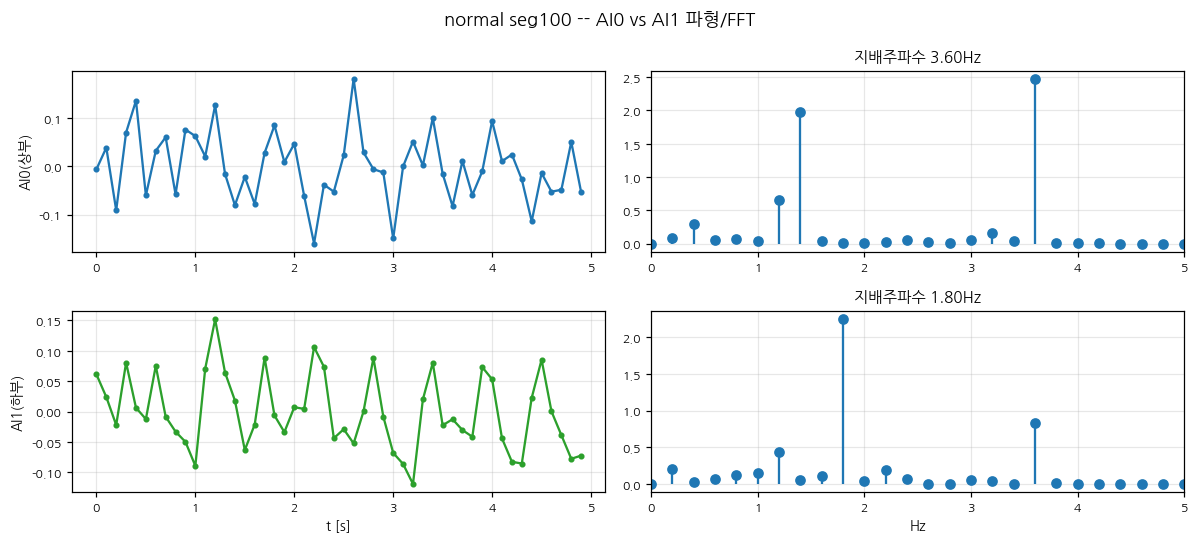

In [23]:
g = SEG["normal"][SEG["normal"].seg_id == 100]
t = np.arange(len(g)) / FS
fig, axes = plt.subplots(2, 2, figsize=(11, 5))
for i, (ch, name, color) in enumerate([("AI0_Vibration","AI0(상부)","#1f77b4"),
                                       ("AI1_Vibration","AI1(하부)","#2ca02c")]):
    x = g[ch].to_numpy()
    axes[i, 0].plot(t, x, "o-", ms=3, color=color); axes[i, 0].set_ylabel(name)
    freqs = np.fft.rfftfreq(len(x), d=1/FS)
    power = np.abs(np.fft.rfft(x - x.mean())) ** 2
    axes[i, 1].stem(freqs, power, basefmt=" ")
    axes[i, 1].set_xlim(0, 5)
    peak = freqs[1:][np.argmax(power[1:])]
    axes[i, 1].set_title(f"지배주파수 {peak:.2f}Hz")
axes[1, 0].set_xlabel("t [s]"); axes[1, 1].set_xlabel("Hz")
fig.suptitle("normal seg100 -- AI0 vs AI1 파형/FFT")
plt.tight_layout(); plt.show()

**결과 (2) 주파수:** n>=15 구간부터 normal AI0 ~3.3-3.5Hz, AI1 ~1.8-1.9Hz로 뚜렷이
갈린다(n<15는 FFT 해상도가 거칠어 구분이 흐려진다 -- 2절에서 이미 지적한 한계와 같다).

**"진동이 덜하다"는 표현은 정정이 필요하다.** rms 비율(AI1/AI0) 중앙값이 1.38로
**AI1이 오히려 더 크다.** 하부는 상부보다 느리게, 하지만 더 크게 흔들린다 -- 주파수가
낮다는 인상이 진폭까지 작다는 뜻은 아니다.

**주파수를 피처로 — 바로 테스트해 본 결과.** 두 채널의 주파수 "차이"(`AI0 peak_hz -
AI1 peak_hz`)를 세그먼트별로 직접 빼서 피처로 만들면 **AUC 0.529로 거의 무의미**하다
(세그먼트 단위로는 두 피크가 느슨하게 따로 움직여서, 집계 중앙값끼리는 뚜렷이 달라도
차이값 자체는 상쇄된다). 대신 **채널별 지배주파수 자체**는 강하다 -- `AI1_Vibration
peak_hz` 단독 AUC **0.952**(n>=15), `AI0_Vibration peak_hz` 단독 AUC **0.881**. 특히
AI1 쪽은 기존 `ai1_rms`(0.852)보다도 좋다. **"차이"가 아니라 "절대 주파수 값"으로
피처를 만들어야 한다**는 게 이번에 확인된 요점이다. 03에서 길이 하한(n>=15~20)과
함께 `ai1_peak_hz`를 정식 후보로 평가해 볼 가치가 있다 -- 채택은 여기서 하지 않는다.